# Avance 4 — AUTH Recommendation Validity vs Current AUTH History

**Proyecto:** Implementación de MLOps para versionado, monitoreo y decisión de retraining en un sistema de recomendación de precios B2B  
**Equipo:** Equipo 46  
**Notebook:** Avance 4 — Monitoreo de vigencia de recomendaciones contra historia AUTH actual

## Propósito del notebook

Este notebook implementa una compuerta de monitoreo **pre-model / pre-scoring**. La pregunta principal no es si una nueva recomendación cambió contra una anterior, porque eso requeriría correr de nuevo el modelo. La pregunta principal es:

> **¿La recomendación vigente generada en el baseline sigue siendo coherente con la historia AUTH actual observada?**

El enfoque correcto para este Avance 4 es:

1. Tomar el `model_output_snapshot.csv` generado en Avance 3 como baseline oficial.
2. Separar la recomendación vigente y la historia AUTH baseline.
3. Construir o cargar una historia AUTH actual.
4. Comparar la recomendación vigente contra los nuevos percentiles AUTH actuales.
5. Generar semáforos para decidir si se mantiene la recomendación, se revisa con Pricing/PM o se justifica una nueva corrida del modelo.

## Alcance AUTH-only

Este monitoreo utiliza únicamente datos **AUTH** como alcance operativo actual. Por lo tanto, las bandas `P20`, `P50` y `P85` se interpretan como corredores de **historia de precios autorizados**, no como mercado completo.

Las alertas no significan automáticamente que el modelo esté mal. Significan que la recomendación vigente debe revisarse frente al comportamiento reciente de autorizaciones.

## Nota sobre bins

Los catálogos de bins fueron creados con todos los datos disponibles, es decir, **AUTH + no AUTH**. En este notebook no se recalculan los catálogos de bins. Lo que se monitorea es cómo se distribuyen los registros AUTH dentro de esos bins ya definidos/versionados. En operación, el catálogo debe tratarse como configuración versionada (`bin_catalog_version`).

## Limitación actual

Los datos reales posteriores al baseline todavía están pendientes de entrega. Para completar y validar la lógica MLOps de esta etapa, el notebook genera una **historia AUTH actual simulada**. Cuando los datos reales estén disponibles, se reemplaza el archivo simulado por un `current_auth_history_snapshot` real, sin cambiar la lógica del monitoreo.

## Nota metodológica clave

Este notebook implementa una compuerta **pre-model / pre-scoring** para el alcance actual **AUTH-only**. No ejecuta nuevamente el modelo de recomendación. Su objetivo es validar si la recomendación vigente generada en el baseline sigue siendo coherente con la historia AUTH actual observada o simulada.

La comparación principal es:

```text
baseline recommendation
vs
current AUTH history
```

Por lo tanto, el semáforo no significa automáticamente que el modelo esté "bien" o "mal". Significa si la recomendación vigente puede mantenerse, debe revisarse o justifica una nueva corrida/recalibración antes de confiar en ella.

También se conserva la distinción de bins: los **catálogos de bins** fueron creados con datos AUTH + no-AUTH, mientras que este monitoreo evalúa la distribución de los registros **AUTH** dentro de ese catálogo global.

Cuando los datos reales posteriores al baseline estén disponibles, la historia AUTH simulada debe reemplazarse por una agregación real generada con el mismo contrato de columnas y llaves.


In [1]:
# =========================================================
# 0. Imports and notebook configuration
# =========================================================

import os
import json
import math
import hashlib
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
except Exception as e:
    raise ImportError(
        "This notebook requires scipy for KS-test and proportion tests. "
        "Install it with: pip install scipy"
    ) from e

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 120)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python: 3.13.1
pandas: 2.2.3
numpy: 2.2.5


## 1. Configuración de la corrida

Esta sección define el alcance del monitoreo, las rutas de entrada/salida y los parámetros de simulación. 

Puntos importantes:

- `MONITORING_SCOPE = AUTH_ONLY`: el análisis se interpreta como historia de autorizaciones.
- `BIN_CATALOG_SCOPE = AUTH_AND_NON_AUTH_GLOBAL`: los bins vienen de catálogos construidos con todos los datos.
- `RUNS_MODEL = False`: este notebook no ejecuta el modelo ni genera nuevas recomendaciones.

In [2]:
# =========================================================
# 1. Run configuration
# =========================================================

PROJECT_NAME = "pricing-mlops"
TEAM = "Equipo46"
ENVIRONMENT = "local_simulated_monitoring"

MONITORING_SCOPE = "AUTH_ONLY"
CURRENT_HISTORY_INTERPRETATION = "authorized_price_history"
BIN_CATALOG_SCOPE = "AUTH_AND_NON_AUTH_GLOBAL"
BIN_CATALOG_VERSION = "global_bins_auth_and_non_auth_v1"
RUNS_MODEL = False

BASELINE_VERSION = "baseline_mlops_pricing_v1"
RECOMMENDATION_VALIDITY_SCHEMA_VERSION = "auth_recommendation_validity_v1"
INPUT_HISTORY_DRIFT_SCHEMA_VERSION = "auth_history_drift_v1"
DATA_QUALITY_SCHEMA_VERSION = "data_quality_log_v1"

RUN_TIMESTAMP_UTC = datetime.now(timezone.utc)
DRIFT_RUN_ID = RUN_TIMESTAMP_UTC.strftime("%Y%m%dT%H%M%SZ") + "_auth_recommendation_validity_v1"

OUTPUT_ROOT = Path("avance4_outputs") / DRIFT_RUN_ID
OUTPUT_DIRS = {
    "snapshots": OUTPUT_ROOT / "snapshots",
    "logs": OUTPUT_ROOT / "logs",
    "summaries": OUTPUT_ROOT / "summaries",
    "reports": OUTPUT_ROOT / "reports",
    "figures": OUTPUT_ROOT / "figures",
    "manifest": OUTPUT_ROOT / "manifest",
}

for path in OUTPUT_DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Baseline snapshot path
# ---------------------------------------------------------------------
# Option 1: set the exact path manually.
# Example:
# BASELINE_SNAPSHOT_PATH = Path("avance3_outputs/20260530T194311Z_baseline_v1/snapshots/model_output_snapshot.csv")

BASELINE_SNAPSHOT_PATH = None

# Option 2: automatic search. It looks for the most recently modified model_output_snapshot.csv.
SEARCH_ROOTS = [Path("."), Path("/mnt/data")]

# Simulation parameters for current AUTH history.
SIMULATION_SEED = 46
SIMULATED_MONTH_SHIFT = 6
REMOVE_FRACTION = 0.06
NEW_COMBO_FRACTION = 0.04

# Minimum support used for dashboard/review interpretation.
# Segments below this threshold are still calculated, but should not drive executive decisions alone.
MIN_SEGMENT_SUPPORT_FOR_DASHBOARD = 30

# Recommendation source policy.
# In production, Selected_Optimal_Price or the official PM-selected strategy should be preferred.
# Balanced is used as a proxy only when no official selected recommendation column exists.
OFFICIAL_RECOMMENDATION_PREFERRED_COLUMNS = ["Selected_Optimal_Price", "selected_recommended_price"]
PROXY_RECOMMENDATION_COLUMNS = ["Balanced", "More_Profit", "Revenue_Aggressive"]

# Thresholds for data quality and monitoring.
ROW_COUNT_RATIO_WARNING_LOW = 0.80
ROW_COUNT_RATIO_WARNING_HIGH = 1.20
CURRENT_HISTORY_COVERAGE_RED_THRESHOLD = 0.85
CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD = 0.95
NEW_COMBO_RATE_YELLOW_THRESHOLD = 0.05
NEW_COMBO_RATE_RED_THRESHOLD = 0.15

PSI_YELLOW = 0.10
PSI_RED = 0.25
KS_YELLOW = 0.05
KS_RED = 0.15
Z_YELLOW = 2.0
Z_RED = 3.5

NEAR_BAND_EDGE_THRESHOLD = 0.15
GAP_VS_P50_YELLOW = 0.10
GAP_VS_P50_RED = 0.20
P50_SHIFT_YELLOW = 0.10
P50_SHIFT_RED = 0.20

GLOBAL_VALIDITY_RED_RATE_THRESHOLD = 0.05
GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD = 0.01
GLOBAL_VALIDITY_RED_REVENUE_SHARE_THRESHOLD = 0.05
GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD = 0.01

print("Drift run ID:", DRIFT_RUN_ID)
print("Output root:", OUTPUT_ROOT)
print("Monitoring scope:", MONITORING_SCOPE)
print("Runs model:", RUNS_MODEL)

Drift run ID: 20260601T042547Z_auth_recommendation_validity_v1
Output root: avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1
Monitoring scope: AUTH_ONLY
Runs model: False


## 2. Carga del baseline oficial de Avance 3

El input principal es el `model_output_snapshot.csv` de Avance 3. Este archivo contiene la recomendación vigente, percentiles históricos AUTH y señales operativas generadas por la corrida baseline.

Si el notebook no encuentra automáticamente el archivo, asigna manualmente la variable `BASELINE_SNAPSHOT_PATH` en la celda anterior.

In [3]:
# =========================================================
# 2. Load baseline model_output_snapshot from Avance 3
# =========================================================

def find_latest_snapshot(search_roots):
    candidates = []
    for root in search_roots:
        if root.exists():
            candidates.extend(root.rglob("model_output_snapshot.csv"))
    candidates = [p for p in candidates if "avance3_outputs" in str(p).lower() or "snapshots" in str(p).lower()]
    if not candidates:
        return None
    return max(candidates, key=lambda p: p.stat().st_mtime)

if BASELINE_SNAPSHOT_PATH is None:
    BASELINE_SNAPSHOT_PATH = find_latest_snapshot(SEARCH_ROOTS)

if BASELINE_SNAPSHOT_PATH is None or not Path(BASELINE_SNAPSHOT_PATH).exists():
    raise FileNotFoundError(
        "Could not find model_output_snapshot.csv. "
        "Set BASELINE_SNAPSHOT_PATH manually in section 1."
    )

BASELINE_SNAPSHOT_PATH = Path(BASELINE_SNAPSHOT_PATH)
baseline_snapshot = pd.read_csv(BASELINE_SNAPSHOT_PATH)

print("Baseline snapshot path:", BASELINE_SNAPSHOT_PATH)
print("Baseline shape:", baseline_snapshot.shape)
display(baseline_snapshot.head())

Baseline snapshot path: masked_data_inputcomplete_inputauth_output\avance3_outputs\20260530T194311Z_baseline_v1\snapshots\model_output_snapshot.csv
Baseline shape: (8314, 119)


,run_id,baseline_version,output_schema_version,run_timestamp_utc,kpn,vpareadescription,distysegment,mean_elasticity,P0_PRICE,P20_PRICE,P50_PRICE,P85_PRICE,P100_PRICE,P0_RESALE,P20_RESALE,P50_RESALE,P85_RESALE,P100_RESALE,P0_QTY,P20_QTY,P35_QTY,P50_QTY,P65_QTY,P85_QTY,P100_QTY,P20,Min_P20_for_5pct_margin,P20_Adjusted_Min5pctMargin,P20_Was_Adjusted,P50,P85,q0,q0_method,q0_local_obs,Revenue_Aggressive,Revenue_Aggressive_QTY_OPT,More_Revenue,More_Revenue_QTY_OPT,Balanced,Balanced_QTY_OPT,More_Profit,More_Profit_QTY_OPT,Profit_Aggressive,Profit_Aggressive_QTY_OPT,s_curve_price_range_p85_p20,s_curve_center_gap_p50_p20,s_curve_upper_gap_p85_p50,s_curve_range_ratio_p85_p20,recommended_below_p20,recommended_above_p85,recommended_outside_p20_p85,recommended_position_p20_p85,recommended_gap_vs_p50,recommended_gap_vs_p50_pct,recommended_near_extreme_zone,recommended_historical_zone,strategy_price_min,strategy_price_max,strategy_price_range,strategy_price_range_ratio,strategy_qty_min,strategy_qty_max,strategy_qty_range,p20_adjustment_amount,p20_adjustment_pct,price_percentiles_monotonic,qty_percentiles_monotonic,q0_local_obs_bin,q0_low_support_flag,n_transactions,n_invoices,revenue_sum,revenue_median,resale_price_median,resale_price_mean,into_stock_price_median,quantity_median,quantity_sum,log_quantity_mean,log_into_stock_price_mean,distributor_margin_pct_median,channel_margin_share_median,kemet_margin_pct_median,negative_distributor_margin_rate,negative_kemet_variable_margin_rate,channel_margin_share_out_of_range_rate,auth_cost_match_rate,elasticity_mean_avg,elasticity_sd_avg,elasticity_hdi_width_avg,order_size_bin_mode,disty_margin_original_bin_mode,channel_margin_share_bin_mode,date_min,date_max,n_distributor_parents,distributor_parentnumber_mode,distributor_parent_top_share,custombusinessgroup_mode,custombusinessgroup_top_share,log1p_revenue_sum,log1p_quantity_sum,log1p_n_transactions,kpn_frequency,vpareadescription_frequency,distysegment_frequency,custombusinessgroup_mode_frequency,distributor_parentnumber_mode_frequency,price_band_width,price_band_is_collapsed,price_band_is_valid,recommended_outside_valid_p20_p85,recommended_band_not_evaluable,revenue_percentile,revenue_weight_bucket,priority_score,impact_points,recommendation_status_final,review_priority_final
0,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,-3.764863,9.848737,9.848737,10.362581,10.404101,10.410032,12.61812,12.80112,13.107570,13.388520,13.78404,6000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,9.848737,6.168000,9.848737,False,10.362581,10.404101,11000.0,local_avg,6,9.848737,13030.022146,9.848737,13030.022146,9.848737,13030.022146,9.848737,13030.022146,9.848737,13030.022146,0.555364,0.513844,0.041520,1.056389,0,0,0,0.0,-0.513844,-0.049587,1,Near_P20,9.848737,9.848737,0.0,1.0,13030.022146,13030.022146,0.0,0.0,0.0,1,1,Medium,0,8,8,1.183797e+06,157345.20000,13.11210,13.131285,10.362581,12000.0,90000.0,9.306019,2.325722,0.214858,0.613404,0.434542,0.0,0.0,0.0,1.0,-3.764863,0.705578,2.625786,Small,Medium,Low,2023-08-28 00:00:00+00:00,2025-05-27 00:00:00+00:00,1,DISTNUM_00000002,1.0,BUSINESSGRP_00000003,1.0,13.984238,11.407576,2.197225,0.000034,0.610649,0.994572,0.020887,0.162336,0.555364,0,1,0,0,0.627376,Low_Impact,3,0,Yellow,Low
1,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,KPN_00000002,VPAREA_00000002,DISTSEG_00000002,-1.180541,7.981792,7.981792,7.981792,7.981792,7.981792,9.44484,9.44484,10.038600,10.632360,10.63236,5832.0,5832.0,5832.0,5832.0,5832.0,5832.0,5832.0,7.981792,4.304615,7.981792,False,7.981792,7.981792,5832.0,local_avg,5,7.981792,5832.000000,7.981792,5832.000000,7.981792,5832.000000,7.981792,5832.000000,7.981792,5832.000000,0.000000,0.000000,0.000000,1.000000,0,0,0,NaN,0.000000,0.000000,0,Missing,7.981792,7.981792,0.0,1.0,5832.000000,5832.000000,0.0,0.0,0.0,1,1,Low,0,5,5,2.961

## 3. Definición de llaves, recomendación vigente e historia AUTH baseline

En este proyecto la granularidad principal de monitoreo es:

`kpn + vpareadescription + distysegment`

La recomendación oficial puede venir de varias columnas. El orden de prioridad usado es:

1. `Selected_Optimal_Price`, si existe.
2. `selected_recommended_price`, si existe.
3. `Balanced`, como proxy.
4. `More_Profit`, como fallback.
5. `Revenue_Aggressive`, como fallback final.

Para esta etapa, si se usa `Balanced`, debe entenderse como proxy de la recomendación vigente. En producción debe usarse la estrategia oficial aprobada por Pricing/PM.

In [4]:
# =========================================================
# 3. Build baseline recommendation snapshot and baseline AUTH history profile
# =========================================================

KEY_COLUMNS = ["kpn", "vpareadescription", "distysegment"]
missing_keys = [c for c in KEY_COLUMNS if c not in baseline_snapshot.columns]
if missing_keys:
    raise ValueError(f"Missing key columns in baseline snapshot: {missing_keys}")

RECOMMENDATION_CANDIDATES = [
    "Selected_Optimal_Price",
    "selected_recommended_price",
    "Balanced",
    "More_Profit",
    "Revenue_Aggressive",
]

RECOMMENDATION_PRICE_COLUMN = next((c for c in RECOMMENDATION_CANDIDATES if c in baseline_snapshot.columns), None)
if RECOMMENDATION_PRICE_COLUMN is None:
    raise ValueError(
        "No recommendation price column found. Expected one of: "
        + ", ".join(RECOMMENDATION_CANDIDATES)
    )

print("Recommendation price column used:", RECOMMENDATION_PRICE_COLUMN)

# Core history columns expected from baseline snapshot.
BASELINE_HISTORY_COLUMNS = [
    "P20_PRICE", "P50_PRICE", "P85_PRICE", "P100_PRICE", "P0_PRICE",
    "P20_RESALE", "P50_RESALE", "P85_RESALE",
    "P20_QTY", "P50_QTY", "P85_QTY",
    "P20", "P50", "P85",
    "Min_P20_for_5pct_margin", "P20_Adjusted_Min5pctMargin", "P20_Was_Adjusted",
    "q0", "q0_local_obs", "n_transactions", "n_invoices",
    "revenue_sum", "quantity_sum", "revenue_median",
    "resale_price_median", "resale_price_mean", "into_stock_price_median",
    "log_quantity_mean", "log_into_stock_price_mean",
    "distributor_margin_pct_median", "channel_margin_share_median", "kemet_margin_pct_median",
    "negative_distributor_margin_rate", "negative_kemet_variable_margin_rate",
    "channel_margin_share_out_of_range_rate", "auth_cost_match_rate",
    "date_min", "date_max", "n_distributor_parents",
    "distributor_parentnumber_mode", "custombusinessgroup_mode",
    "price_band_width", "price_band_is_collapsed", "price_band_is_valid",
]

# Bin columns: created using global AUTH + non-AUTH catalog, monitored only over AUTH scope here.
GLOBAL_BIN_COLUMNS = [
    "q0_local_obs_bin",
    "order_size_bin_mode",
    "disty_margin_original_bin_mode",
    "channel_margin_share_bin_mode",
    "revenue_weight_bucket",
    "recommended_historical_zone",
    "recommendation_status_final",
    "review_priority_final",
]

history_cols_available = [c for c in BASELINE_HISTORY_COLUMNS if c in baseline_snapshot.columns]
bin_cols_available = [c for c in GLOBAL_BIN_COLUMNS if c in baseline_snapshot.columns]

baseline_recommendation_snapshot = baseline_snapshot[
    KEY_COLUMNS + [RECOMMENDATION_PRICE_COLUMN]
    + [c for c in ["run_id", "baseline_version", "output_schema_version", "run_timestamp_utc"] if c in baseline_snapshot.columns]
].copy()

baseline_recommendation_snapshot = baseline_recommendation_snapshot.rename(
    columns={RECOMMENDATION_PRICE_COLUMN: "baseline_recommended_price"}
)

baseline_auth_history_profile = baseline_snapshot[
    KEY_COLUMNS + history_cols_available + bin_cols_available
].copy()

# Add explicit interpretation fields.
baseline_recommendation_snapshot["recommendation_source_column"] = RECOMMENDATION_PRICE_COLUMN
baseline_recommendation_snapshot["monitoring_scope"] = MONITORING_SCOPE
baseline_auth_history_profile["history_scope"] = MONITORING_SCOPE
baseline_auth_history_profile["bin_catalog_scope"] = BIN_CATALOG_SCOPE
baseline_auth_history_profile["bin_catalog_version"] = BIN_CATALOG_VERSION

print("Baseline recommendation snapshot shape:", baseline_recommendation_snapshot.shape)
print("Baseline AUTH history profile shape:", baseline_auth_history_profile.shape)
print("Available global bin columns:", bin_cols_available)

display(baseline_recommendation_snapshot.head())
display(baseline_auth_history_profile.head())

Recommendation price column used: Balanced
Baseline recommendation snapshot shape: (8314, 10)
Baseline AUTH history profile shape: (8314, 58)
Available global bin columns: ['q0_local_obs_bin', 'order_size_bin_mode', 'disty_margin_original_bin_mode', 'channel_margin_share_bin_mode', 'revenue_weight_bucket', 'recommended_historical_zone', 'recommendation_status_final', 'review_priority_final']


,kpn,vpareadescription,distysegment,baseline_recommended_price,run_id,baseline_version,output_schema_version,run_timestamp_utc,recommendation_source_column,monitoring_scope
0,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,9.848737,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY
1,KPN_00000002,VPAREA_00000002,DISTSEG_00000002,7.981792,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY
2,KPN_00000003,VPAREA_00000002,DISTSEG_00000002,10.775419,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY
3,KPN_00000004,VPAREA_00000002,DISTSEG_00000002,6.553356,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY
4,KPN_00000005,VPAREA_00000002,DISTSEG_00000002,10.436982,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY


,kpn,vpareadescription,distysegment,P20_PRICE,P50_PRICE,P85_PRICE,P100_PRICE,P0_PRICE,P20_RESALE,P50_RESALE,P85_RESALE,P20_QTY,P50_QTY,P85_QTY,P20,P50,P85,Min_P20_for_5pct_margin,P20_Adjusted_Min5pctMargin,P20_Was_Adjusted,q0,q0_local_obs,n_transactions,n_invoices,revenue_sum,quantity_sum,revenue_median,resale_price_median,resale_price_mean,into_stock_price_median,log_quantity_mean,log_into_stock_price_mean,distributor_margin_pct_median,channel_margin_share_median,kemet_margin_pct_median,negative_distributor_margin_rate,negative_kemet_variable_margin_rate,channel_margin_share_out_of_range_rate,auth_cost_match_rate,date_min,date_max,n_distributor_parents,distributor_parentnumber_mode,custombusinessgroup_mode,price_band_width,price_band_is_collapsed,price_band_is_valid,q0_local_obs_bin,order_size_bin_mode,disty_margin_original_bin_mode,channel_margin_share_bin_mode,revenue_weight_bucket,recommended_historical_zone,recommendation_status_final,review_priority_final,history_scope,bin_catalog_scope,bin_catalog_version
0,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,9.848737,10.362581,10.404101,10.410032,9.848737,12.80112,13.107570,13.388520,12000.0,12000.0,12000.0,9.848737,10.362581,10.404101,6.168000,9.848737,False,11000.0,6,8,8,1.183797e+06,90000.0,157345.20000,13.11210,13.131285,10.362581,9.306019,2.325722,0.214858,0.613404,0.434542,0.0,0.0,0.0,1.0,2023-08-28 00:00:00+00:00,2025-05-27 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000003,0.555364,0,1,Medium,Small,Medium,Low,Low_Impact,Near_P20,Yellow,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1
1,KPN_00000002,VPAREA_00000002,DISTSEG_00000002,7.981792,7.981792,7.981792,7.981792,7.981792,9.44484,10.038600,10.632360,5832.0,5832.0,5832.0,7.981792,7.981792,7.981792,4.304615,7.981792,False,5832.0,5,5,5,2.961884e+05,29160.0,62007.92352,10.63236,10.157352,7.981792,8.671115,2.077163,0.249293,0.594899,0.487661,0.0,0.0,0.0,1.0,2025-03-12 00:00:00+00:00,2025-07-21 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000002,0.000000,1,0,Low,Small,Medium,Medium,Low_Impact,Missing,Green,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1
2,KPN_00000003,VPAREA_00000002,DISTSEG_00000002,10.775419,10.775419,10.775419,10.775419,10.775419,12.74304,13.083816,13.967561,5160.0,5160.0,9133.2,10.775419,10.775419,10.775419,6.701495,10.775419,False,6966.0,4,4,4,3.750623e+05,27864.0,72818.53920,13.87896,13.711560,10.775419,8.767559,2.377267,0.223615,0.586885,0.409172,0.0,0.0,0.0,1.0,2025-03-11 00:00:00+00:00,2025-07-28 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000002,0.000000,1,0,Low,Small,Low,Medium,Low_Impact,Missing,Green,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1
3,KPN_00000004,VPAREA_00000002,DISTSEG_00000002,6.553356,6.553356,6.553356,6.553356,6.553356,7.24752,7.247520,7.247520,7776.0,7776.0,7776.0,6.553356,6.553356,6.553356,5.448657,6.553356,False,7776.0,1,1,1,5.635672e+04,7776.0,56356.71552,7.24752,7.247520,6.553356,8.958797,1.879977,0.095780,0.664865,0.210141,0.0,0.0,0.0,1.0,2023-10-31 00:00:00+00:00,2023-10-31 00:00:00+00:00,1,DISTNUM_00000001,BUSINESSGRP_00000002,0.000000,1,0,Very_Low,Small,Low,Medium,Low_Impact,Missing,Green,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1
4,KPN_00000005,VPAREA_00000002,DISTSEG_00000002,10.436982,10.436982,10.466174,10.490058,10.436982,13.22136,13.356780,13.681554,5280.0,5280.0,5280.0,10.436982,10.436982,10.466174,6.676547,10.436982,False,5280.0,3,3,3,2.141042e+05,15840.0,71238.81600,13.49220,13.516680,10.436982,8.571681,2.347046,0.226443,0.572666,0.392284,0.0,0.0,0.0,1.0,2023-10-17 00:00:00+00:00,2024-09-02 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000002,0.029191,0,1,Low,Small,Medium,Low,Low_Impact,Near_P20,Yellow,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1


### 3.1 Interpretación de la columna de recomendación

El monitoreo necesita una única columna que represente la recomendación vigente. En producción, esta debería ser la recomendación oficialmente seleccionada por Pricing/PM, por ejemplo `Selected_Optimal_Price`.

Si esa columna no existe, el notebook usa `Balanced` como proxy metodológico. Esto es aceptable para el MVP académico, pero debe quedar registrado para trazabilidad porque el semáforo puede cambiar si negocio selecciona otra estrategia como recomendación oficial.


In [5]:
# =========================================================
# 3.1 Recommendation source interpretation
# =========================================================

official_recommendation_columns_available = [
    col for col in OFFICIAL_RECOMMENDATION_PREFERRED_COLUMNS
    if col in baseline_snapshot.columns
]

is_official_recommendation_source = RECOMMENDATION_PRICE_COLUMN in official_recommendation_columns_available
is_proxy_recommendation_source = not is_official_recommendation_source

recommendation_source_metadata = {
    "recommendation_source_column": RECOMMENDATION_PRICE_COLUMN,
    "is_official_recommendation_source": bool(is_official_recommendation_source),
    "is_proxy_recommendation_source": bool(is_proxy_recommendation_source),
    "source_interpretation": (
        "Official selected recommendation column was used."
        if is_official_recommendation_source
        else "Proxy recommendation column was used. Replace with official PM-selected recommendation in production."
    ),
    "monitoring_scope": MONITORING_SCOPE,
    "runs_model": RUNS_MODEL,
}

recommendation_source_metadata_df = pd.DataFrame([recommendation_source_metadata])
display(recommendation_source_metadata_df)


,recommendation_source_column,is_official_recommendation_source,is_proxy_recommendation_source,source_interpretation,monitoring_scope,runs_model
0,Balanced,False,True,Proxy recommendation column was used. Replace with official PM-selected recommendation in production.,AUTH_ONLY,False


## 4. Simulación de historia AUTH actual sin correr el modelo

Esta sección genera un `current_auth_history_snapshot_simulated`. No genera nuevas recomendaciones.

La simulación busca ser razonable para validar el mecanismo:

- Algunos combos dejan de estar activos.
- Aparecen algunos combos nuevos sin recomendación vigente.
- Se desplazan fechas seis meses.
- Cambian moderadamente precios, revenue, cantidades y márgenes.
- Los percentiles mantienen su orden correcto/esperado.
- Los bins se tratan como asignaciones a categorías existentes de un catálogo global AUTH + no AUTH.

Cuando se reciban datos reales, esta sección se reemplaza por la carga/agregación real de historia AUTH actual.

In [6]:
# =========================================================
# 4. Simulate current AUTH history without running the model
# =========================================================

rng = np.random.default_rng(SIMULATION_SEED)

base_hist = baseline_auth_history_profile.copy()
base_hist["_baseline_row_id"] = np.arange(len(base_hist))

# ---------------------------------------------------------------------
# 4.1 Remove a realistic fraction of existing combos.
# Higher probability of removal for low support / low revenue combos.
# ---------------------------------------------------------------------
remove_score = np.ones(len(base_hist), dtype=float)

if "n_transactions" in base_hist.columns:
    tx = pd.to_numeric(base_hist["n_transactions"], errors="coerce").fillna(0)
    remove_score *= np.where(tx <= tx.quantile(0.25), 1.8, 1.0)

if "revenue_sum" in base_hist.columns:
    rev = pd.to_numeric(base_hist["revenue_sum"], errors="coerce").fillna(0)
    remove_score *= np.where(rev <= rev.quantile(0.25), 1.5, 1.0)

remove_prob = remove_score / remove_score.sum()
n_remove = int(round(len(base_hist) * REMOVE_FRACTION))
remove_idx = rng.choice(base_hist.index.to_numpy(), size=n_remove, replace=False, p=remove_prob)
current_existing = base_hist.drop(index=remove_idx).copy()
current_existing["current_record_type"] = "existing_combo"

# ---------------------------------------------------------------------
# 4.2 Segment-level market/history shifts.
# These are history shifts, not new model recommendations.
# ---------------------------------------------------------------------
segment_cols_for_shift = [c for c in ["vpareadescription", "distysegment", "custombusinessgroup_mode"] if c in current_existing.columns]

if segment_cols_for_shift:
    segment_keys = current_existing[segment_cols_for_shift].astype(str).agg("|".join, axis=1)
    unique_segments = sorted(segment_keys.unique())
    segment_price_shift = {seg: rng.normal(loc=1.02, scale=0.05) for seg in unique_segments}
    segment_qty_shift = {seg: rng.normal(loc=1.01, scale=0.08) for seg in unique_segments}
    segment_revenue_shift = {seg: rng.normal(loc=1.04, scale=0.10) for seg in unique_segments}
    price_factor = segment_keys.map(segment_price_shift).astype(float).to_numpy()
    qty_factor = segment_keys.map(segment_qty_shift).astype(float).to_numpy()
    revenue_factor = segment_keys.map(segment_revenue_shift).astype(float).to_numpy()
else:
    price_factor = rng.normal(loc=1.02, scale=0.05, size=len(current_existing))
    qty_factor = rng.normal(loc=1.01, scale=0.08, size=len(current_existing))
    revenue_factor = rng.normal(loc=1.04, scale=0.10, size=len(current_existing))

# Row-level noise.
price_factor = np.clip(price_factor * rng.normal(loc=1.00, scale=0.03, size=len(current_existing)), 0.75, 1.35)
qty_factor = np.clip(qty_factor * rng.normal(loc=1.00, scale=0.06, size=len(current_existing)), 0.55, 1.65)
revenue_factor = np.clip(revenue_factor * rng.normal(loc=1.00, scale=0.08, size=len(current_existing)), 0.50, 1.90)

PRICE_HISTORY_COLS = [c for c in ["P0_PRICE", "P20_PRICE", "P50_PRICE", "P85_PRICE", "P100_PRICE", "P20", "P50", "P85", "P20_RESALE", "P50_RESALE", "P85_RESALE", "resale_price_median", "resale_price_mean", "into_stock_price_median"] if c in current_existing.columns]
QTY_HISTORY_COLS = [c for c in ["P20_QTY", "P50_QTY", "P85_QTY", "q0", "quantity_sum", "log_quantity_mean"] if c in current_existing.columns]
REVENUE_HISTORY_COLS = [c for c in ["revenue_sum", "revenue_median"] if c in current_existing.columns]

for col in PRICE_HISTORY_COLS:
    current_existing[col] = pd.to_numeric(current_existing[col], errors="coerce") * price_factor

for col in QTY_HISTORY_COLS:
    current_existing[col] = pd.to_numeric(current_existing[col], errors="coerce") * qty_factor

for col in REVENUE_HISTORY_COLS:
    current_existing[col] = pd.to_numeric(current_existing[col], errors="coerce") * revenue_factor

# Margin shifts: modest changes in observed AUTH economics.
for col in ["distributor_margin_pct_median", "channel_margin_share_median", "kemet_margin_pct_median"]:
    if col in current_existing.columns:
        current_existing[col] = pd.to_numeric(current_existing[col], errors="coerce") + rng.normal(0, 0.015, size=len(current_existing))

# Rates remain bounded in [0, 1].
for col in ["negative_distributor_margin_rate", "negative_kemet_variable_margin_rate", "channel_margin_share_out_of_range_rate", "auth_cost_match_rate"]:
    if col in current_existing.columns:
        current_existing[col] = pd.to_numeric(current_existing[col], errors="coerce") + rng.normal(0, 0.01, size=len(current_existing))
        current_existing[col] = current_existing[col].clip(0, 1)

# ---------------------------------------------------------------------
# 4.3 Preserve percentile monotonicity.
# ---------------------------------------------------------------------
def enforce_monotonic_columns(df, cols):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return df
    values = df[cols].apply(pd.to_numeric, errors="coerce")
    values_sorted = np.sort(values.to_numpy(dtype=float), axis=1)
    df.loc[:, cols] = values_sorted
    return df

current_existing = enforce_monotonic_columns(current_existing, ["P0_PRICE", "P20_PRICE", "P50_PRICE", "P85_PRICE", "P100_PRICE"])
current_existing = enforce_monotonic_columns(current_existing, ["P20", "P50", "P85"])
current_existing = enforce_monotonic_columns(current_existing, ["P20_RESALE", "P50_RESALE", "P85_RESALE"])
current_existing = enforce_monotonic_columns(current_existing, ["P20_QTY", "P50_QTY", "P85_QTY"])

if {"P85_PRICE", "P20_PRICE"}.issubset(current_existing.columns):
    current_existing["price_band_width"] = pd.to_numeric(current_existing["P85_PRICE"], errors="coerce") - pd.to_numeric(current_existing["P20_PRICE"], errors="coerce")
    current_existing["price_band_is_valid"] = (current_existing["price_band_width"] > 0).astype(int)
    current_existing["price_band_is_collapsed"] = (current_existing["price_band_width"] <= 0).astype(int)

# Shift dates forward if available.
for date_col in ["date_min", "date_max"]:
    if date_col in current_existing.columns:
        current_existing[date_col] = pd.to_datetime(current_existing[date_col], errors="coerce") + pd.DateOffset(months=SIMULATED_MONTH_SHIFT)

# ---------------------------------------------------------------------
# 4.4 Simulate changes in global bin assignments among AUTH records.
# Bin catalogs are not recreated; categories are existing/known labels.
# ---------------------------------------------------------------------
def shift_category_values(series, frac, target_value, random_state):
    if series.name is None:
        name = "category"
    rng_local = np.random.default_rng(random_state)
    s = series.copy().astype("object")
    valid_idx = s.dropna().index.to_numpy()
    if len(valid_idx) == 0:
        return s
    n = int(round(len(valid_idx) * frac))
    if n == 0:
        return s
    idx = rng_local.choice(valid_idx, size=n, replace=False)
    s.loc[idx] = target_value
    return s

if "revenue_weight_bucket" in current_existing.columns:
    # Simulate modest movement from low to medium/high impact among AUTH current rows.
    current_existing["revenue_weight_bucket"] = shift_category_values(
        current_existing["revenue_weight_bucket"], frac=0.05, target_value="Medium_Impact", random_state=SIMULATION_SEED + 101
    )

if "order_size_bin_mode" in current_existing.columns:
    current_existing["order_size_bin_mode"] = shift_category_values(
        current_existing["order_size_bin_mode"], frac=0.04, target_value="Medium", random_state=SIMULATION_SEED + 102
    )

if "disty_margin_original_bin_mode" in current_existing.columns:
    current_existing["disty_margin_original_bin_mode"] = shift_category_values(
        current_existing["disty_margin_original_bin_mode"], frac=0.03, target_value="Low", random_state=SIMULATION_SEED + 103
    )

# Important: output-derived bins like recommendation_status_final are not recalculated here as new output.
# They may be retained for baseline context, but recommendation validity is calculated separately below.

# ---------------------------------------------------------------------
# 4.5 Add new combos with current AUTH history but no baseline recommendation.
# These represent new KPN/segment combinations that require model coverage review.
# ---------------------------------------------------------------------
n_new = int(round(len(base_hist) * NEW_COMBO_FRACTION))
new_source = base_hist.sample(n=n_new, replace=True, random_state=SIMULATION_SEED + 200).copy()
new_source["current_record_type"] = "new_combo_no_baseline_recommendation"
new_source["_baseline_row_id"] = -1

# Generate new masked KPN ids.
new_source["kpn"] = [f"KPN_NEW_{i+1:06d}" for i in range(n_new)]

# Apply slightly larger uncertainty to new combos.
new_price_factor = rng.normal(loc=1.05, scale=0.08, size=n_new).clip(0.70, 1.45)
new_qty_factor = rng.normal(loc=0.95, scale=0.20, size=n_new).clip(0.35, 1.80)
new_rev_factor = rng.normal(loc=1.00, scale=0.25, size=n_new).clip(0.20, 2.30)

for col in PRICE_HISTORY_COLS:
    if col in new_source.columns:
        new_source[col] = pd.to_numeric(new_source[col], errors="coerce") * new_price_factor
for col in QTY_HISTORY_COLS:
    if col in new_source.columns:
        new_source[col] = pd.to_numeric(new_source[col], errors="coerce") * new_qty_factor
for col in REVENUE_HISTORY_COLS:
    if col in new_source.columns:
        new_source[col] = pd.to_numeric(new_source[col], errors="coerce") * new_rev_factor

new_source = enforce_monotonic_columns(new_source, ["P0_PRICE", "P20_PRICE", "P50_PRICE", "P85_PRICE", "P100_PRICE"])
new_source = enforce_monotonic_columns(new_source, ["P20", "P50", "P85"])
new_source = enforce_monotonic_columns(new_source, ["P20_RESALE", "P50_RESALE", "P85_RESALE"])
new_source = enforce_monotonic_columns(new_source, ["P20_QTY", "P50_QTY", "P85_QTY"])

if {"P85_PRICE", "P20_PRICE"}.issubset(new_source.columns):
    new_source["price_band_width"] = pd.to_numeric(new_source["P85_PRICE"], errors="coerce") - pd.to_numeric(new_source["P20_PRICE"], errors="coerce")
    new_source["price_band_is_valid"] = (new_source["price_band_width"] > 0).astype(int)
    new_source["price_band_is_collapsed"] = (new_source["price_band_width"] <= 0).astype(int)

for date_col in ["date_min", "date_max"]:
    if date_col in new_source.columns:
        new_source[date_col] = pd.to_datetime(new_source[date_col], errors="coerce") + pd.DateOffset(months=SIMULATED_MONTH_SHIFT)

current_auth_history = pd.concat([current_existing, new_source], ignore_index=True)
current_auth_history["history_scope"] = MONITORING_SCOPE
current_auth_history["history_snapshot_type"] = "simulated_current_auth_history"
current_auth_history["simulation_seed"] = SIMULATION_SEED
current_auth_history["simulated_month_shift"] = SIMULATED_MONTH_SHIFT
current_auth_history["bin_catalog_scope"] = BIN_CATALOG_SCOPE
current_auth_history["bin_catalog_version"] = BIN_CATALOG_VERSION

# Keep readable date columns in CSV.
for date_col in ["date_min", "date_max"]:
    if date_col in current_auth_history.columns:
        current_auth_history[date_col] = pd.to_datetime(current_auth_history[date_col], errors="coerce").astype(str)

simulation_summary = {
    "baseline_rows": int(len(base_hist)),
    "current_rows": int(len(current_auth_history)),
    "rows_removed": int(n_remove),
    "new_combos": int(n_new),
    "remove_fraction": REMOVE_FRACTION,
    "new_combo_fraction": NEW_COMBO_FRACTION,
    "simulated_month_shift": SIMULATED_MONTH_SHIFT,
    "runs_model": RUNS_MODEL,
    "monitoring_scope": MONITORING_SCOPE,
    "bin_catalog_scope": BIN_CATALOG_SCOPE,
}

print(json.dumps(simulation_summary, indent=2))
print("Current AUTH history shape:", current_auth_history.shape)
display(current_auth_history.head())

{
  "baseline_rows": 8314,
  "current_rows": 8148,
  "rows_removed": 499,
  "new_combos": 333,
  "remove_fraction": 0.06,
  "new_combo_fraction": 0.04,
  "simulated_month_shift": 6,
  "runs_model": false,
  "monitoring_scope": "AUTH_ONLY",
  "bin_catalog_scope": "AUTH_AND_NON_AUTH_GLOBAL"
}
Current AUTH history shape: (8148, 63)


,kpn,vpareadescription,distysegment,P20_PRICE,P50_PRICE,P85_PRICE,P100_PRICE,P0_PRICE,P20_RESALE,P50_RESALE,P85_RESALE,P20_QTY,P50_QTY,P85_QTY,P20,P50,P85,Min_P20_for_5pct_margin,P20_Adjusted_Min5pctMargin,P20_Was_Adjusted,q0,q0_local_obs,n_transactions,n_invoices,revenue_sum,quantity_sum,revenue_median,resale_price_median,resale_price_mean,into_stock_price_median,log_quantity_mean,log_into_stock_price_mean,distributor_margin_pct_median,channel_margin_share_median,kemet_margin_pct_median,negative_distributor_margin_rate,negative_kemet_variable_margin_rate,channel_margin_share_out_of_range_rate,auth_cost_match_rate,date_min,date_max,n_distributor_parents,distributor_parentnumber_mode,custombusinessgroup_mode,price_band_width,price_band_is_collapsed,price_band_is_valid,q0_local_obs_bin,order_size_bin_mode,disty_margin_original_bin_mode,channel_margin_share_bin_mode,revenue_weight_bucket,recommended_historical_zone,recommendation_status_final,review_priority_final,history_scope,bin_catalog_scope,bin_catalog_version,_baseline_row_id,current_record_type,history_snapshot_type,simulation_seed,simulated_month_shift
0,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,10.143056,10.672256,10.715016,10.721125,10.143056,13.183668,13.499276,13.788622,13732.349138,13732.349138,13732.349138,10.143056,10.672256,10.715016,6.168000,9.848737,False,12587.986710,6,8,8,1.094788e+06,102992.618533,145514.602806,13.503941,13.523700,10.672256,10.649458,2.325722,0.206606,0.609226,0.439688,0.001151,0.015544,0.000000,0.990134,2024-02-28 00:00:00+00:00,2025-11-27 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000003,0.571961,0,1,Medium,Medium,Medium,Low,Low_Impact,Near_P20,Yellow,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,0,existing_combo,simulated_current_auth_history,46,6
1,KPN_00000002,VPAREA_00000002,DISTSEG_00000002,8.415794,8.415794,8.415794,8.415794,8.415794,9.958395,10.584440,11.210485,5289.708823,5289.708823,5289.708823,8.415794,8.415794,8.415794,4.304615,7.981792,False,5289.708823,5,5,5,3.430677e+05,26448.544117,71822.244922,11.210485,10.709649,8.415794,7.864828,2.077163,0.229789,0.587996,0.474039,0.006127,0.000000,0.000000,1.000000,2025-09-12 00:00:00+00:00,2026-01-21 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000002,0.000000,1,0,Low,Small,Medium,Medium,Low_Impact,Missing,Green,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,1,existing_combo,simulated_current_auth_history,46,6
2,KPN_00000003,VPAREA_00000002,DISTSEG_00000002,11.713584,11.713584,11.713584,11.713584,11.713584,13.852517,14.222963,15.183651,4549.727299,4549.727299,8053.017319,11.713584,11.713584,11.713584,6.701495,10.775419,False,6142.131853,4,4,4,4.597090e+05,24568.527413,89252.740684,15.087336,14.905361,11.713584,7.730621,2.377267,0.216559,0.593158,0.404892,0.001877,0.003070,0.000000,1.000000,2025-09-11 00:00:00+00:00,2026-01-28 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000002,0.000000,1,0,Low,Small,Low,Medium,Low_Impact,Missing,Green,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,2,existing_combo,simulated_current_auth_history,46,6
3,KPN_00000004,VPAREA_00000002,DISTSEG_00000002,7.254128,7.254128,7.254128,7.254128,7.254128,8.022521,8.022521,8.022521,7936.457154,7936.457154,7936.457154,7.254128,7.254128,7.254128,5.448657,6.553356,False,7936.457154,1,1,1,6.133509e+04,7936.457154,61335.088960,8.022521,8.022521,7.254128,9.143661,1.879977,0.074404,0.671285,0.217087,0.012194,0.000000,0.013416,1.000000,2024-04-30 00:00:00+00:00,2024-04-30 00:00:00+00:00,1,DISTNUM_00000001,BUSINESSGRP_00000002,0.000000,1,0,Very_Low,Small,Low,Medium,Low_Impact,Missing,Green,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,3,existing_combo,simulated_current_auth_history,46,6
4,KPN_00000005,VPAREA_00000002,DISTSEG_00000002,11.181454,11.181454,11.212728,11.238315,11.181454,14.164442,14.309522,14.657462,5052.112201,5052.112201,5052.112201,11.181454,11.181454,11.212728,6.676547,10.436982,False,5052.112201

## 5. Data Quality Log

Antes de calcular drift o vigencia de recomendaciones, se valida si los snapshots son comparables.

Este log responde:

> ¿La historia AUTH actual es suficientemente válida para monitoreo?

No responde todavía si hay drift; solo verifica calidad y contrato básico.

In [7]:
# =========================================================
# 5. Data quality log
# =========================================================

quality_records = []

def add_quality_check(dataset_name, check_name, check_status, observed_value=None, threshold_value=None, details=None):
    quality_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "dataset_name": dataset_name,
        "check_name": check_name,
        "check_status": check_status,
        "observed_value": observed_value,
        "threshold_value": threshold_value,
        "details": details,
        "timestamp_utc": RUN_TIMESTAMP_UTC.isoformat(),
        "monitoring_scope": MONITORING_SCOPE,
    })

# Required columns
required_baseline_cols = KEY_COLUMNS + ["baseline_recommended_price"]
missing_baseline_rec_cols = [c for c in required_baseline_cols if c not in baseline_recommendation_snapshot.columns]
add_quality_check(
    "baseline_recommendation_snapshot",
    "required_recommendation_columns_present",
    "PASS" if not missing_baseline_rec_cols else "FAIL",
    observed_value=len(missing_baseline_rec_cols),
    threshold_value=0,
    details=f"Missing columns: {missing_baseline_rec_cols}",
)

required_history_cols = KEY_COLUMNS + ["P20_PRICE", "P50_PRICE", "P85_PRICE"]
missing_current_history_cols = [c for c in required_history_cols if c not in current_auth_history.columns]
add_quality_check(
    "current_auth_history",
    "required_current_history_columns_present",
    "PASS" if not missing_current_history_cols else "FAIL",
    observed_value=len(missing_current_history_cols),
    threshold_value=0,
    details=f"Missing columns: {missing_current_history_cols}",
)

# Row counts
add_quality_check("baseline_recommendation_snapshot", "row_count_positive", "PASS" if len(baseline_recommendation_snapshot) > 0 else "FAIL", len(baseline_recommendation_snapshot), ">0")
add_quality_check("current_auth_history", "row_count_positive", "PASS" if len(current_auth_history) > 0 else "FAIL", len(current_auth_history), ">0")

row_count_ratio = len(current_auth_history) / max(len(baseline_auth_history_profile), 1)
row_status = "PASS" if ROW_COUNT_RATIO_WARNING_LOW <= row_count_ratio <= ROW_COUNT_RATIO_WARNING_HIGH else "WARNING"
add_quality_check(
    "baseline_vs_current",
    "row_count_ratio_within_expected_range",
    row_status,
    observed_value=row_count_ratio,
    threshold_value=f"[{ROW_COUNT_RATIO_WARNING_LOW}, {ROW_COUNT_RATIO_WARNING_HIGH}]",
    details="Ratio = current_auth_history_rows / baseline_auth_history_rows",
)

# Uniqueness by grain.
def duplicate_rate(df, keys):
    if not set(keys).issubset(df.columns):
        return np.nan
    return float(df.duplicated(keys).mean())

baseline_dup_rate = duplicate_rate(baseline_recommendation_snapshot, KEY_COLUMNS)
current_dup_rate = duplicate_rate(current_auth_history, KEY_COLUMNS)
add_quality_check("baseline_recommendation_snapshot", "grain_uniqueness", "PASS" if baseline_dup_rate == 0 else "FAIL", baseline_dup_rate, 0)
add_quality_check("current_auth_history", "grain_uniqueness", "PASS" if current_dup_rate == 0 else "FAIL", current_dup_rate, 0)

# Price monotonicity.
def monotonic_rate(df, cols):
    cols = [c for c in cols if c in df.columns]
    if len(cols) < 2:
        return np.nan
    values = df[cols].apply(pd.to_numeric, errors="coerce")
    valid_rows = values.notna().all(axis=1)
    if valid_rows.sum() == 0:
        return np.nan
    diffs = values.loc[valid_rows].diff(axis=1).iloc[:, 1:]
    return float((diffs >= -1e-12).all(axis=1).mean())

for dataset_name, df in [("baseline_auth_history", baseline_auth_history_profile), ("current_auth_history", current_auth_history)]:
    rate = monotonic_rate(df, ["P0_PRICE", "P20_PRICE", "P50_PRICE", "P85_PRICE", "P100_PRICE"])
    status = "PASS" if pd.isna(rate) or rate >= 0.99 else "FAIL"
    add_quality_check(dataset_name, "price_percentiles_monotonic", status, rate, ">=0.99")

# Non-negative prices.
for dataset_name, df in [("baseline_auth_history", baseline_auth_history_profile), ("current_auth_history", current_auth_history)]:
    price_cols = [c for c in ["P20_PRICE", "P50_PRICE", "P85_PRICE"] if c in df.columns]
    if price_cols:
        min_price = df[price_cols].apply(pd.to_numeric, errors="coerce").min().min()
        status = "PASS" if pd.isna(min_price) or min_price >= 0 else "FAIL"
        add_quality_check(dataset_name, "non_negative_core_prices", status, min_price, ">=0")

# Null rates in critical columns.
for dataset_name, df, cols in [
    ("baseline_recommendation_snapshot", baseline_recommendation_snapshot, ["baseline_recommended_price"]),
    ("current_auth_history", current_auth_history, ["P20_PRICE", "P50_PRICE", "P85_PRICE"]),
]:
    for col in cols:
        if col in df.columns:
            null_rate = float(df[col].isna().mean())
            status = "PASS" if null_rate <= 0.01 else "WARNING" if null_rate <= 0.05 else "FAIL"
            add_quality_check(dataset_name, f"null_rate_{col}", status, null_rate, "<=0.01 PASS; <=0.05 WARNING")

# Coverage of baseline recommendations in current history.
baseline_keys = set(map(tuple, baseline_recommendation_snapshot[KEY_COLUMNS].astype(str).to_numpy()))
current_keys = set(map(tuple, current_auth_history[KEY_COLUMNS].astype(str).to_numpy()))
matched_keys = baseline_keys.intersection(current_keys)
coverage_rate = len(matched_keys) / max(len(baseline_keys), 1)

if coverage_rate < CURRENT_HISTORY_COVERAGE_RED_THRESHOLD:
    coverage_status = "FAIL"
elif coverage_rate < CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD:
    coverage_status = "WARNING"
else:
    coverage_status = "PASS"

add_quality_check(
    "baseline_vs_current",
    "current_history_coverage_of_baseline_recommendations",
    coverage_status,
    observed_value=coverage_rate,
    threshold_value=f">={CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD} PASS; <{CURRENT_HISTORY_COVERAGE_RED_THRESHOLD} FAIL",
    details="Share of baseline recommendation keys found in current AUTH history.",
)

# New combo rate.
new_combo_rate = len(current_keys - baseline_keys) / max(len(current_keys), 1)
if new_combo_rate >= NEW_COMBO_RATE_RED_THRESHOLD:
    new_combo_status = "FAIL"
elif new_combo_rate >= NEW_COMBO_RATE_YELLOW_THRESHOLD:
    new_combo_status = "WARNING"
else:
    new_combo_status = "PASS"

add_quality_check(
    "baseline_vs_current",
    "new_combo_rate_without_baseline_recommendation",
    new_combo_status,
    observed_value=new_combo_rate,
    threshold_value=f"Yellow>={NEW_COMBO_RATE_YELLOW_THRESHOLD}; Red>={NEW_COMBO_RATE_RED_THRESHOLD}",
    details="Share of current AUTH combos without baseline recommendation.",
)

# Bin catalog metadata available.
add_quality_check(
    "monitoring_configuration",
    "bin_catalog_scope_declared",
    "PASS" if BIN_CATALOG_SCOPE == "AUTH_AND_NON_AUTH_GLOBAL" else "WARNING",
    observed_value=BIN_CATALOG_SCOPE,
    threshold_value="AUTH_AND_NON_AUTH_GLOBAL",
    details="Bins are monitored over AUTH rows but catalog was created globally with AUTH + non-AUTH data.",
)

data_quality_log = pd.DataFrame(quality_records)
quality_status_summary = (
    data_quality_log.groupby(["dataset_name", "check_status"])
    .size()
    .reset_index(name="n_checks")
)

display(data_quality_log)
display(quality_status_summary)

,drift_run_id,dataset_name,check_name,check_status,observed_value,threshold_value,details,timestamp_utc,monitoring_scope
0,20260601T042547Z_auth_recommendation_validity_v1,baseline_recommendation_snapshot,required_recommendation_columns_present,PASS,0,0,Missing columns: [],2026-06-01T04:25:47.338517+00:00,AUTH_ONLY
1,20260601T042547Z_auth_recommendation_validity_v1,current_auth_history,required_current_history_columns_present,PASS,0,0,Missing columns: [],2026-06-01T04:25:47.338517+00:00,AUTH_ONLY
2,20260601T042547Z_auth_recommendation_validity_v1,baseline_recommendation_snapshot,row_count_positive,PASS,8314,>0,None,2026-06-01T04:25:47.338517+00:00,AUTH_ONLY
3,20260601T042547Z_auth_recommendation_validity_v1,current_auth_history,row_count_positive,PASS,8148,>0,None,2026-06-01T04:25:47.338517+00:00,AUTH_ONLY
4,20260601T042547Z_auth_recommendation_validity_v1,baseline_vs_current,row_count_ratio_within_expected_range,PASS,0.980034,"[0.8, 1.2]",Ratio = current_auth_history_rows / baseline_auth_history_rows,2026-06-01T04:25:47.338517+00:00,AUTH_ONLY
5,20260601T042547Z_auth_recommendation_validity_v1,baseline_recommendation_snapshot,grain_uniqueness,PASS,0.0,0,None,2026-06-01T04:25:47.338517+00:00,AUTH_ONLY
6,20260601T042547Z_auth_recommendation_validity_v1,current_auth_history,grain_uniqueness,PASS,0.0,0,None,2026-06-01T04:25:47.338517+00:00,AUTH_ONLY
7,20260601T042547Z_auth_recommendation_validity_v1,baseline_auth_history,price_percentiles_monotonic,PASS,1.0,>=0.99,None,2026-06-01T04:25:47.338517+00:00,AUTH_ONLY
8,20260601T042547Z_auth_recommendation_validity_v1,current_auth_history,price_percentiles_monotonic,PASS,1.0,>=0.99,None,2026-06-01T04:25:47.338517+00:00,AUTH_ONLY
9,20260601T042547Z_auth_recommendation_validity_v1,baseline_auth_history,non_negative_core_prices,PASS,0.0144,>=0,None,2026-06-01T04:25:47.338517+00:00,AUTH_ONLY


,dataset_name,check_status,n_checks
0,baseline_auth_history,PASS,2
1,baseline_recommendation_snapshot,PASS,4
2,baseline_vs_current,PASS,2
3,baseline_vs_current,WARNING,1
4,current_auth_history,PASS,8
5,monitoring_configuration,PASS,1


## 6. Métricas de drift para historia AUTH

Esta sección compara la historia AUTH baseline contra la historia AUTH actual simulada. No usa recomendaciones nuevas.

El objetivo es saber si cambió la población o comportamiento histórico antes de decidir mantener/revisar/correr modelo.

In [8]:
# =========================================================
# 6. Drift utility functions
# =========================================================

def calculate_numeric_psi(expected, actual, bins=10, epsilon=1e-6):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    if expected.nunique() <= 1:
        return 0.0 if actual.nunique() <= 1 else np.nan
    breakpoints = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(breakpoints) < 3:
        return np.nan
    expected_counts = pd.cut(expected, bins=breakpoints, include_lowest=True, duplicates="drop").value_counts(sort=False)
    actual_counts = pd.cut(actual, bins=breakpoints, include_lowest=True, duplicates="drop").value_counts(sort=False)
    expected_pct = (expected_counts / expected_counts.sum()).replace(0, epsilon)
    actual_pct = (actual_counts / actual_counts.sum()).replace(0, epsilon)
    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())


def calculate_categorical_psi(expected, actual, epsilon=1e-6):
    expected = pd.Series(expected).fillna("__MISSING__").astype(str)
    actual = pd.Series(actual).fillna("__MISSING__").astype(str)
    categories = sorted(set(expected.unique()).union(set(actual.unique())))
    expected_pct = expected.value_counts(normalize=True).reindex(categories, fill_value=0).replace(0, epsilon)
    actual_pct = actual.value_counts(normalize=True).reindex(categories, fill_value=0).replace(0, epsilon)
    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())


def calculate_ks_statistic(expected, actual):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if len(expected) == 0 or len(actual) == 0:
        return np.nan, np.nan
    result = stats.ks_2samp(expected, actual)
    return float(result.statistic), float(result.pvalue)


def classify_metric_status(value, yellow_threshold, red_threshold, higher_is_worse=True):
    if pd.isna(value):
        return "Not_Evaluable"
    if higher_is_worse:
        if value >= red_threshold:
            return "Red"
        elif value >= yellow_threshold:
            return "Yellow"
        else:
            return "Green"
    else:
        if value <= red_threshold:
            return "Red"
        elif value <= yellow_threshold:
            return "Yellow"
        else:
            return "Green"


def status_to_action(status, stage="history"):
    if status == "Green":
        return "No action / Continue monitoring"
    if status == "Yellow":
        return "Review with Pricing / PM"
    if status == "Red":
        if stage == "validity":
            return "Review recommendation; consider running model"
        return "Review data/history drift before relying on recommendation"
    return "Review metric availability"

In [9]:
# =========================================================
# 6.1 Calculate AUTH history drift log
# =========================================================

NUMERIC_HISTORY_VARIABLES = [
    "P20_PRICE", "P50_PRICE", "P85_PRICE",
    "P20", "P50", "P85",
    "revenue_sum", "quantity_sum", "n_transactions", "n_invoices",
    "log_quantity_mean", "log_into_stock_price_mean",
    "distributor_margin_pct_median", "channel_margin_share_median", "kemet_margin_pct_median",
    "negative_distributor_margin_rate", "negative_kemet_variable_margin_rate",
    "price_band_width",
]

CATEGORICAL_HISTORY_VARIABLES = [
    "vpareadescription", "distysegment", "custombusinessgroup_mode",
    "distributor_parentnumber_mode",
] + bin_cols_available

KS_HISTORY_VARIABLES = [
    "P50_PRICE", "revenue_sum", "quantity_sum", "distributor_margin_pct_median", "price_band_width"
]

numeric_history_vars = [c for c in NUMERIC_HISTORY_VARIABLES if c in baseline_auth_history_profile.columns and c in current_auth_history.columns]
categorical_history_vars = [c for c in CATEGORICAL_HISTORY_VARIABLES if c in baseline_auth_history_profile.columns and c in current_auth_history.columns]
ks_history_vars = [c for c in KS_HISTORY_VARIABLES if c in baseline_auth_history_profile.columns and c in current_auth_history.columns]

drift_records = []

for col in numeric_history_vars:
    psi = calculate_numeric_psi(baseline_auth_history_profile[col], current_auth_history[col], bins=10)
    status = classify_metric_status(psi, PSI_YELLOW, PSI_RED)
    drift_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "auth_history_pre_model",
        "variable_name": col,
        "variable_type": "numeric",
        "drift_metric": "PSI",
        "drift_value": psi,
        "p_value": np.nan,
        "threshold_yellow": PSI_YELLOW,
        "threshold_red": PSI_RED,
        "drift_status": status,
        "recommended_action": status_to_action(status, stage="history"),
        "monitoring_scope": MONITORING_SCOPE,
    })

for col in categorical_history_vars:
    psi = calculate_categorical_psi(baseline_auth_history_profile[col], current_auth_history[col])
    status = classify_metric_status(psi, PSI_YELLOW, PSI_RED)
    drift_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "auth_history_pre_model",
        "variable_name": col,
        "variable_type": "categorical",
        "drift_metric": "Categorical_PSI",
        "drift_value": psi,
        "p_value": np.nan,
        "threshold_yellow": PSI_YELLOW,
        "threshold_red": PSI_RED,
        "drift_status": status,
        "recommended_action": status_to_action(status, stage="history"),
        "monitoring_scope": MONITORING_SCOPE,
    })

for col in ks_history_vars:
    ks_stat, p_value = calculate_ks_statistic(baseline_auth_history_profile[col], current_auth_history[col])
    status = classify_metric_status(ks_stat, KS_YELLOW, KS_RED)
    drift_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "auth_history_pre_model",
        "variable_name": col,
        "variable_type": "numeric",
        "drift_metric": "KS",
        "drift_value": ks_stat,
        "p_value": p_value,
        "threshold_yellow": KS_YELLOW,
        "threshold_red": KS_RED,
        "drift_status": status,
        "recommended_action": status_to_action(status, stage="history"),
        "monitoring_scope": MONITORING_SCOPE,
    })

# Coverage metrics as drift/monitoring signals.
coverage_status = "Red" if coverage_rate < CURRENT_HISTORY_COVERAGE_RED_THRESHOLD else "Yellow" if coverage_rate < CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD else "Green"
new_combo_signal_status = "Red" if new_combo_rate >= NEW_COMBO_RATE_RED_THRESHOLD else "Yellow" if new_combo_rate >= NEW_COMBO_RATE_YELLOW_THRESHOLD else "Green"

for metric_name, metric_value, status, yellow, red, action in [
    ("current_history_coverage_rate", coverage_rate, coverage_status, CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD, CURRENT_HISTORY_COVERAGE_RED_THRESHOLD, "Review missing baseline recommendation coverage"),
    ("new_combo_rate_without_recommendation", new_combo_rate, new_combo_signal_status, NEW_COMBO_RATE_YELLOW_THRESHOLD, NEW_COMBO_RATE_RED_THRESHOLD, "Review new combos requiring recommendation coverage"),
]:
    drift_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "coverage_pre_model",
        "variable_name": metric_name,
        "variable_type": "coverage",
        "drift_metric": "Coverage_Rate",
        "drift_value": metric_value,
        "p_value": np.nan,
        "threshold_yellow": yellow,
        "threshold_red": red,
        "drift_status": status,
        "recommended_action": action,
        "monitoring_scope": MONITORING_SCOPE,
    })

input_history_drift_log = pd.DataFrame(drift_records)

display(input_history_drift_log.sort_values(["drift_status", "drift_metric", "variable_name"]))

,drift_run_id,monitoring_stage,variable_name,variable_type,drift_metric,drift_value,p_value,threshold_yellow,threshold_red,drift_status,recommended_action,monitoring_scope
25,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,channel_margin_share_bin_mode,categorical,Categorical_PSI,1.060257e-05,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
20,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,custombusinessgroup_mode,categorical,Categorical_PSI,1.585892e-05,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
21,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,distributor_parentnumber_mode,categorical,Categorical_PSI,1.486851e-04,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
24,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,disty_margin_original_bin_mode,categorical,Categorical_PSI,1.461213e-03,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
19,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,distysegment,categorical,Categorical_PSI,8.483875e-08,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
23,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,order_size_bin_mode,categorical,Categorical_PSI,1.394888e-02,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
22,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,q0_local_obs_bin,categorical,Categorical_PSI,3.535470e-04,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
28,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,recommendation_status_final,categorical,Categorical_PSI,2.117784e-04,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
27,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,recommended_historical_zone,categorical,Categorical_PSI,2.475618e-04,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
26,20260601T042547Z_auth_recommendation_validity_v1,auth_history_pre_model,revenue_weight_bucket,categorical,Categorical_PSI,1.188878e-02,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY


## 7. Vigencia de recomendación contra historia AUTH actual

Esta es la sección central del Avance 4.

Aquí se compara:

`baseline_recommended_price`  
contra  
`current AUTH P20 / P50 / P85`

No se genera una recomendación nueva. Se valida si la recomendación vigente sigue siendo defendible frente a la historia AUTH actual.

In [10]:
# =========================================================
# 7. Recommendation validity vs current AUTH history
# =========================================================

# Prepare current history columns with current_ prefix, except keys.
current_cols_for_join = [c for c in current_auth_history.columns if c not in ["_baseline_row_id"]]
current_prefixed = current_auth_history[current_cols_for_join].copy()
current_prefixed = current_prefixed.rename(columns={c: f"current_{c}" for c in current_prefixed.columns if c not in KEY_COLUMNS})

baseline_hist_for_join = baseline_auth_history_profile.copy()
baseline_hist_for_join = baseline_hist_for_join.rename(columns={c: f"baseline_{c}" for c in baseline_hist_for_join.columns if c not in KEY_COLUMNS})

validity_df = (
    baseline_recommendation_snapshot
    .merge(baseline_hist_for_join, on=KEY_COLUMNS, how="left")
    .merge(current_prefixed, on=KEY_COLUMNS, how="left")
)

# Ensure numeric columns.
for col in ["baseline_recommended_price", "current_P20_PRICE", "current_P50_PRICE", "current_P85_PRICE", "baseline_P20_PRICE", "baseline_P50_PRICE", "baseline_P85_PRICE"]:
    if col in validity_df.columns:
        validity_df[col] = pd.to_numeric(validity_df[col], errors="coerce")

# Core validity calculations.
validity_df["has_current_auth_history"] = validity_df["current_P20_PRICE"].notna() & validity_df["current_P50_PRICE"].notna() & validity_df["current_P85_PRICE"].notna()
validity_df["current_auth_band_width"] = validity_df["current_P85_PRICE"] - validity_df["current_P20_PRICE"]
validity_df["current_auth_band_is_valid"] = validity_df["current_auth_band_width"] > 0

validity_df["recommendation_below_current_auth_p20"] = validity_df["baseline_recommended_price"] < validity_df["current_P20_PRICE"]
validity_df["recommendation_above_current_auth_p85"] = validity_df["baseline_recommended_price"] > validity_df["current_P85_PRICE"]
validity_df["recommendation_outside_current_auth_band"] = (
    validity_df["recommendation_below_current_auth_p20"] | validity_df["recommendation_above_current_auth_p85"]
)

validity_df["recommendation_position_current_auth_band"] = np.where(
    validity_df["current_auth_band_is_valid"],
    (validity_df["baseline_recommended_price"] - validity_df["current_P20_PRICE"]) / validity_df["current_auth_band_width"],
    np.nan,
)

validity_df["recommendation_gap_vs_current_auth_p50"] = validity_df["baseline_recommended_price"] - validity_df["current_P50_PRICE"]
validity_df["recommendation_gap_vs_current_auth_p50_pct"] = np.where(
    validity_df["current_P50_PRICE"].abs() > 1e-12,
    validity_df["recommendation_gap_vs_current_auth_p50"] / validity_df["current_P50_PRICE"],
    np.nan,
)

validity_df["current_auth_p50_shift_vs_baseline_pct"] = np.where(
    validity_df["baseline_P50_PRICE"].abs() > 1e-12,
    (validity_df["current_P50_PRICE"] - validity_df["baseline_P50_PRICE"]) / validity_df["baseline_P50_PRICE"],
    np.nan,
)

validity_df["recommendation_near_current_auth_band_edge"] = (
    validity_df["recommendation_position_current_auth_band"].between(0, NEAR_BAND_EDGE_THRESHOLD, inclusive="both") |
    validity_df["recommendation_position_current_auth_band"].between(1 - NEAR_BAND_EDGE_THRESHOLD, 1, inclusive="both")
)

validity_df["recommendation_far_from_current_auth_p50_yellow"] = validity_df["recommendation_gap_vs_current_auth_p50_pct"].abs() >= GAP_VS_P50_YELLOW
validity_df["recommendation_far_from_current_auth_p50_red"] = validity_df["recommendation_gap_vs_current_auth_p50_pct"].abs() >= GAP_VS_P50_RED
validity_df["current_auth_history_shift_yellow"] = validity_df["current_auth_p50_shift_vs_baseline_pct"].abs() >= P50_SHIFT_YELLOW
validity_df["current_auth_history_shift_red"] = validity_df["current_auth_p50_shift_vs_baseline_pct"].abs() >= P50_SHIFT_RED

# Optional margin floor check if available.
if "current_Min_P20_for_5pct_margin" in validity_df.columns:
    validity_df["current_margin_floor_risk"] = validity_df["baseline_recommended_price"] < pd.to_numeric(validity_df["current_Min_P20_for_5pct_margin"], errors="coerce")
else:
    validity_df["current_margin_floor_risk"] = False

# Revenue weight used for impact.
if "baseline_revenue_sum" in validity_df.columns:
    validity_df["baseline_revenue_sum_numeric"] = pd.to_numeric(validity_df["baseline_revenue_sum"], errors="coerce").fillna(0)
else:
    validity_df["baseline_revenue_sum_numeric"] = 0.0

# Status and reason.
def classify_recommendation_validity(row):
    if not bool(row.get("has_current_auth_history", False)):
        return "Not_Evaluable", "No current AUTH history for this baseline recommendation"
    if not bool(row.get("current_auth_band_is_valid", False)):
        return "Yellow", "Current AUTH band is collapsed or invalid"
    if bool(row.get("current_margin_floor_risk", False)):
        return "Red", "Recommendation below current margin floor"
    if bool(row.get("recommendation_below_current_auth_p20", False)):
        return "Red", "Recommendation below current AUTH P20"
    if bool(row.get("recommendation_above_current_auth_p85", False)):
        return "Red", "Recommendation above current AUTH P85"
    if bool(row.get("recommendation_far_from_current_auth_p50_red", False)):
        return "Red", "Recommendation far from current AUTH P50"
    if bool(row.get("current_auth_history_shift_red", False)):
        return "Yellow", "Current AUTH P50 shifted strongly vs baseline; review before keeping recommendation"
    if bool(row.get("recommendation_near_current_auth_band_edge", False)):
        return "Yellow", "Recommendation near current AUTH band edge"
    if bool(row.get("recommendation_far_from_current_auth_p50_yellow", False)):
        return "Yellow", "Recommendation moderately far from current AUTH P50"
    if bool(row.get("current_auth_history_shift_yellow", False)):
        return "Yellow", "Current AUTH P50 shifted moderately vs baseline"
    return "Green", "Recommendation aligned with current AUTH history"

status_reason = validity_df.apply(classify_recommendation_validity, axis=1, result_type="expand")
validity_df["auth_recommendation_validity_status"] = status_reason[0]
validity_df["auth_recommendation_validity_reason"] = status_reason[1]

validity_action_map = {
    "Green": "Keep current recommendation / no model run required",
    "Yellow": "Review with Pricing / PM before keeping recommendation",
    "Red": "Run model or recalibrate/review before relying on recommendation",
    "Not_Evaluable": "Review coverage; no current AUTH history available",
}
validity_df["recommended_action"] = validity_df["auth_recommendation_validity_status"].map(validity_action_map)
validity_df["monitoring_stage"] = "recommendation_validity_pre_model"
validity_df["monitoring_scope"] = MONITORING_SCOPE
validity_df["runs_model"] = RUNS_MODEL

# New combos without baseline recommendation.
current_keys_df = current_auth_history[KEY_COLUMNS].drop_duplicates().copy()
baseline_keys_df = baseline_recommendation_snapshot[KEY_COLUMNS].drop_duplicates().copy()
new_combo_log = (
    current_keys_df
    .merge(baseline_keys_df.assign(has_baseline_recommendation=True), on=KEY_COLUMNS, how="left")
)
new_combo_log = new_combo_log[new_combo_log["has_baseline_recommendation"].isna()].drop(columns=["has_baseline_recommendation"])
new_combo_log["coverage_status"] = "New_Combo_No_Baseline_Recommendation"
new_combo_log["recommended_action"] = "Review coverage; generate recommendation when model run is approved"

validity_summary = (
    validity_df["auth_recommendation_validity_status"]
    .value_counts(dropna=False)
    .rename_axis("auth_recommendation_validity_status")
    .reset_index(name="n_recommendations")
)
validity_summary["share"] = validity_summary["n_recommendations"] / len(validity_df)

# Revenue-weighted summary.
revenue_total = validity_df["baseline_revenue_sum_numeric"].sum()
validity_revenue_summary = (
    validity_df.groupby("auth_recommendation_validity_status", dropna=False)["baseline_revenue_sum_numeric"]
    .sum()
    .reset_index(name="baseline_revenue_sum")
)
validity_revenue_summary["baseline_revenue_share"] = np.where(
    revenue_total > 0,
    validity_revenue_summary["baseline_revenue_sum"] / revenue_total,
    np.nan,
)

print("Recommendation validity summary:")
display(validity_summary)
print("Revenue-weighted validity summary:")
display(validity_revenue_summary)
print("New combos without baseline recommendation:", len(new_combo_log))
display(validity_df.head())

Recommendation validity summary:


,auth_recommendation_validity_status,n_recommendations,share
0,Yellow,4859,0.584436
1,Red,2689,0.323430
2,Not_Evaluable,499,0.060019
3,Green,267,0.032115


Revenue-weighted validity summary:


,auth_recommendation_validity_status,baseline_revenue_sum,baseline_revenue_share
0,Green,1.228438e+09,0.042638
1,Not_Evaluable,1.379261e+09,0.047873
2,Red,1.577417e+10,0.547504
3,Yellow,1.042918e+10,0.361985


New combos without baseline recommendation: 333


,kpn,vpareadescription,distysegment,baseline_recommended_price,run_id,baseline_version,output_schema_version,run_timestamp_utc,recommendation_source_column,monitoring_scope,baseline_P20_PRICE,baseline_P50_PRICE,baseline_P85_PRICE,baseline_P100_PRICE,baseline_P0_PRICE,baseline_P20_RESALE,baseline_P50_RESALE,baseline_P85_RESALE,baseline_P20_QTY,baseline_P50_QTY,baseline_P85_QTY,baseline_P20,baseline_P50,baseline_P85,baseline_Min_P20_for_5pct_margin,baseline_P20_Adjusted_Min5pctMargin,baseline_P20_Was_Adjusted,baseline_q0,baseline_q0_local_obs,baseline_n_transactions,baseline_n_invoices,baseline_revenue_sum,baseline_quantity_sum,baseline_revenue_median,baseline_resale_price_median,baseline_resale_price_mean,baseline_into_stock_price_median,baseline_log_quantity_mean,baseline_log_into_stock_price_mean,baseline_distributor_margin_pct_median,baseline_channel_margin_share_median,baseline_kemet_margin_pct_median,baseline_negative_distributor_margin_rate,baseline_negative_kemet_variable_margin_rate,baseline_channel_margin_share_out_of_range_rate,baseline_auth_cost_match_rate,baseline_date_min,baseline_date_max,baseline_n_distributor_parents,baseline_distributor_parentnumber_mode,baseline_custombusinessgroup_mode,baseline_price_band_width,baseline_price_band_is_collapsed,baseline_price_band_is_valid,baseline_q0_local_obs_bin,baseline_order_size_bin_mode,baseline_disty_margin_original_bin_mode,baseline_channel_margin_share_bin_mode,baseline_revenue_weight_bucket,baseline_recommended_historical_zone,baseline_recommendation_status_final,baseline_review_priority_final,baseline_history_scope,baseline_bin_catalog_scope,baseline_bin_catalog_version,current_P20_PRICE,current_P50_PRICE,current_P85_PRICE,current_P100_PRICE,current_P0_PRICE,current_P20_RESALE,current_P50_RESALE,current_P85_RESALE,current_P20_QTY,current_P50_QTY,current_P85_QTY,current_P20,current_P50,current_P85,current_Min_P20_for_5pct_margin,current_P20_Adjusted_Min5pctMargin,current_P20_Was_Adjusted,current_q0,current_q0_local_obs,current_n_transactions,current_n_invoices,current_revenue_sum,current_quantity_sum,current_revenue_median,current_resale_price_median,current_resale_price_mean,current_into_stock_price_median,current_log_quantity_mean,current_log_into_stock_price_mean,current_distributor_margin_pct_median,current_channel_margin_share_median,current_kemet_margin_pct_median,current_negative_distributor_margin_rate,current_negative_kemet_variable_margin_rate,current_channel_margin_share_out_of_range_rate,current_auth_cost_match_rate,current_date_min,current_date_max,current_n_distributor_parents,current_distributor_parentnumber_mode,current_custombusinessgroup_mode,current_price_band_width,current_price_band_is_collapsed,current_price_band_is_valid,current_q0_local_obs_bin,current_order_size_bin_mode,current_disty_margin_original_bin_mode,current_channel_margin_share_bin_mode,current_revenue_weight_bucket,current_recommended_historical_zone,current_recommendation_status_final,current_review_priority_final,current_history_scope,current_bin_catalog_scope,current_bin_catalog_version,current_current_record_type,current_history_snapshot_type,current_simulation_seed,current_simulated_month_shift,has_current_auth_history,current_auth_band_width,current_auth_band_is_valid,recommendation_below_current_auth_p20,recommendation_above_current_auth_p85,recommendation_outside_current_auth_band,recommendation_position_current_auth_band,recommendation_gap_vs_current_auth_p50,recommendation_gap_vs_current_auth_p50_pct,current_auth_p50_shift_vs_baseline_pct,recommendation_near_current_auth_band_edge,recommendation_far_from_current_auth_p50_yellow,recommendation_far_from_current_auth_p50_red,current_auth_history_shift_yellow,current_auth_history_shift_red,current_margin_floor_risk,baseline_revenue_sum_numeric,auth_recommendation_validity_status,auth_recommendation_validity_reason,recommended_action,monitoring_stage,runs_model
0,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,9.848737,20260530

## 8. Semáforos finales

Se separan cuatro estados:

1. `data_quality_status`: calidad de los snapshots para monitoreo.
2. `auth_history_drift_status`: cambio de historia AUTH antes de correr modelo.
3. `auth_recommendation_validity_status`: vigencia de la recomendación contra historia AUTH actual.
4. `run_readiness_status`: decisión operacional: mantener, revisar o correr modelo.

In [11]:
# =========================================================
# 8. Final statuses and run readiness decision
# =========================================================

def aggregate_status(statuses):
    statuses = set(pd.Series(statuses).dropna())
    if "FAIL" in statuses:
        return "Red"
    if "Red" in statuses:
        return "Red"
    if "WARNING" in statuses:
        return "Yellow"
    if "Yellow" in statuses:
        return "Yellow"
    if "PASS" in statuses or "Green" in statuses:
        return "Green"
    return "Not_Evaluable"

# Data quality global.
quality_statuses = data_quality_log["check_status"].replace({"FAIL": "Red", "WARNING": "Yellow", "PASS": "Green"})
data_quality_status = aggregate_status(quality_statuses)

# History drift global.
auth_history_drift_status = aggregate_status(input_history_drift_log["drift_status"])

# Recommendation validity global based on rates and revenue shares.
red_rate = float((validity_df["auth_recommendation_validity_status"] == "Red").mean())
yellow_rate = float((validity_df["auth_recommendation_validity_status"] == "Yellow").mean())
not_eval_rate = float((validity_df["auth_recommendation_validity_status"] == "Not_Evaluable").mean())

red_revenue_share = float(validity_revenue_summary.loc[
    validity_revenue_summary["auth_recommendation_validity_status"].eq("Red"),
    "baseline_revenue_share"
].sum())
yellow_revenue_share = float(validity_revenue_summary.loc[
    validity_revenue_summary["auth_recommendation_validity_status"].eq("Yellow"),
    "baseline_revenue_share"
].sum())

if red_rate >= GLOBAL_VALIDITY_RED_RATE_THRESHOLD or red_revenue_share >= GLOBAL_VALIDITY_RED_REVENUE_SHARE_THRESHOLD:
    recommendation_validity_global_status = "Red"
elif red_rate >= GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD or yellow_rate >= GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD or red_revenue_share >= GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD or yellow_revenue_share >= GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD:
    recommendation_validity_global_status = "Yellow"
else:
    recommendation_validity_global_status = "Green"

# Run readiness decision.
if data_quality_status == "Red":
    run_readiness_status = "Red"
    run_readiness_decision = "Do not rely on monitoring result; fix data quality first."
elif recommendation_validity_global_status == "Red":
    run_readiness_status = "Red"
    run_readiness_decision = "Current recommendations require review; running/recalibrating the model is justified before relying on them."
elif auth_history_drift_status == "Red":
    run_readiness_status = "Yellow"
    run_readiness_decision = "History changed materially; review with Pricing/PM before keeping recommendations or running model."
elif recommendation_validity_global_status == "Yellow" or auth_history_drift_status == "Yellow" or data_quality_status == "Yellow":
    run_readiness_status = "Yellow"
    run_readiness_decision = "Review selected segments/cases; model run may be needed depending on business impact."
else:
    run_readiness_status = "Green"
    run_readiness_decision = "Current recommendations remain aligned with current AUTH history; no model run required."

run_readiness_summary = {
    "drift_run_id": DRIFT_RUN_ID,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC.isoformat(),
    "monitoring_scope": MONITORING_SCOPE,
    "current_history_interpretation": CURRENT_HISTORY_INTERPRETATION,
    "runs_model": RUNS_MODEL,
    "baseline_snapshot_path": str(BASELINE_SNAPSHOT_PATH),
    "recommendation_source_column": RECOMMENDATION_PRICE_COLUMN,
    "bin_catalog_scope": BIN_CATALOG_SCOPE,
    "bin_catalog_version": BIN_CATALOG_VERSION,
    "baseline_recommendation_rows": int(len(baseline_recommendation_snapshot)),
    "current_auth_history_rows": int(len(current_auth_history)),
    "new_combo_count": int(len(new_combo_log)),
    "new_combo_rate": float(new_combo_rate),
    "current_history_coverage_rate": float(coverage_rate),
    "data_quality_status": data_quality_status,
    "auth_history_drift_status": auth_history_drift_status,
    "recommendation_validity_global_status": recommendation_validity_global_status,
    "run_readiness_status": run_readiness_status,
    "run_readiness_decision": run_readiness_decision,
    "green_recommendation_rate": float((validity_df["auth_recommendation_validity_status"] == "Green").mean()),
    "yellow_recommendation_rate": yellow_rate,
    "red_recommendation_rate": red_rate,
    "not_evaluable_recommendation_rate": not_eval_rate,
    "red_revenue_share": red_revenue_share,
    "yellow_revenue_share": yellow_revenue_share,
}

run_readiness_summary_df = pd.DataFrame([run_readiness_summary])
display(run_readiness_summary_df)

,drift_run_id,run_timestamp_utc,monitoring_scope,current_history_interpretation,runs_model,baseline_snapshot_path,recommendation_source_column,bin_catalog_scope,bin_catalog_version,baseline_recommendation_rows,current_auth_history_rows,new_combo_count,new_combo_rate,current_history_coverage_rate,data_quality_status,auth_history_drift_status,recommendation_validity_global_status,run_readiness_status,run_readiness_decision,green_recommendation_rate,yellow_recommendation_rate,red_recommendation_rate,not_evaluable_recommendation_rate,red_revenue_share,yellow_revenue_share
0,20260601T042547Z_auth_recommendation_validity_v1,2026-06-01T04:25:47.338517+00:00,AUTH_ONLY,authorized_price_history,False,masked_data_inputcomplete_inputauth_output\avance3_outputs\20260530T194311Z_baseline_v1\snapshots\model_output_snaps...,Balanced,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,8314,8148,333,0.040869,0.939981,Yellow,Yellow,Red,Red,Current recommendations require review; running/recalibrating the model is justified before relying on them.,0.032115,0.584436,0.32343,0.060019,0.547504,0.361985


## 9. Segmentos y casos principales para revisión

Esta sección identifica dónde se concentran los casos Red/Yellow, usando la granularidad de negocio disponible.

In [12]:
# =========================================================
# 9. Segment and top case summaries
# =========================================================

segment_group_cols = [c for c in ["vpareadescription", "distysegment", "baseline_custombusinessgroup_mode"] if c in validity_df.columns]
if not segment_group_cols:
    segment_group_cols = [c for c in ["vpareadescription", "distysegment"] if c in validity_df.columns]

if segment_group_cols:
    segment_validity_summary = (
        validity_df
        .groupby(segment_group_cols, dropna=False)
        .agg(
            n_recommendations=("baseline_recommended_price", "size"),
            baseline_revenue_sum=("baseline_revenue_sum_numeric", "sum"),
            green_rate=("auth_recommendation_validity_status", lambda s: (s == "Green").mean()),
            yellow_rate=("auth_recommendation_validity_status", lambda s: (s == "Yellow").mean()),
            red_rate=("auth_recommendation_validity_status", lambda s: (s == "Red").mean()),
            not_evaluable_rate=("auth_recommendation_validity_status", lambda s: (s == "Not_Evaluable").mean()),
            avg_gap_vs_current_auth_p50_pct=("recommendation_gap_vs_current_auth_p50_pct", "mean"),
            avg_current_auth_p50_shift_vs_baseline_pct=("current_auth_p50_shift_vs_baseline_pct", "mean"),
        )
        .reset_index()
    )
    segment_validity_summary["baseline_revenue_share"] = segment_validity_summary["baseline_revenue_sum"] / max(segment_validity_summary["baseline_revenue_sum"].sum(), 1e-12)
    segment_validity_summary = segment_validity_summary.sort_values(["red_rate", "baseline_revenue_sum"], ascending=[False, False])
else:
    segment_validity_summary = pd.DataFrame()

# Top review cases.
status_rank = {"Red": 3, "Yellow": 2, "Not_Evaluable": 1, "Green": 0}
validity_df["_status_rank"] = validity_df["auth_recommendation_validity_status"].map(status_rank).fillna(0)

top_recommendation_review_cases = (
    validity_df
    .sort_values(["_status_rank", "baseline_revenue_sum_numeric"], ascending=[False, False])
    .head(100)
    .drop(columns=["_status_rank"], errors="ignore")
)

print("Segment validity summary:")
display(segment_validity_summary.head(30))
print("Top recommendation review cases:")
display(top_recommendation_review_cases[KEY_COLUMNS + [
    "baseline_recommended_price", "current_P20_PRICE", "current_P50_PRICE", "current_P85_PRICE",
    "recommendation_position_current_auth_band", "recommendation_gap_vs_current_auth_p50_pct",
    "current_auth_p50_shift_vs_baseline_pct", "auth_recommendation_validity_status",
    "auth_recommendation_validity_reason", "recommended_action", "baseline_revenue_sum_numeric"
]].head(30))

# Add minimum support interpretation for dashboard usage.
if not segment_validity_summary.empty:
    segment_validity_summary["segment_support_status"] = np.where(
        segment_validity_summary["n_recommendations"] >= MIN_SEGMENT_SUPPORT_FOR_DASHBOARD,
        "Sufficient_Support",
        "Low_Support"
    )
    segment_validity_summary["dashboard_include_flag"] = (
        segment_validity_summary["n_recommendations"] >= MIN_SEGMENT_SUPPORT_FOR_DASHBOARD
    )
    segment_validity_summary["segment_review_priority_score"] = (
        100 * segment_validity_summary["baseline_revenue_share"].fillna(0)
        + 50 * segment_validity_summary["red_rate"].fillna(0)
        + 20 * segment_validity_summary["yellow_rate"].fillna(0)
    )

    segment_dashboard_summary = (
        segment_validity_summary
        .query("dashboard_include_flag == True")
        .sort_values(["segment_review_priority_score", "baseline_revenue_sum"], ascending=[False, False])
        .copy()
    )
else:
    segment_dashboard_summary = pd.DataFrame()

# Executive view for PM / Pricing review.
executive_review_columns = [
    "vpareadescription", "distysegment", "baseline_custombusinessgroup_mode",
    "n_recommendations", "baseline_revenue_share", "red_rate", "yellow_rate", "green_rate",
    "not_evaluable_rate", "avg_gap_vs_current_auth_p50_pct",
    "avg_current_auth_p50_shift_vs_baseline_pct", "segment_support_status",
    "segment_review_priority_score"
]
executive_review_columns = [c for c in executive_review_columns if c in segment_dashboard_summary.columns]

print("Segment dashboard summary, sufficient support only:")
display(segment_dashboard_summary[executive_review_columns].head(15))


Segment validity summary:


,vpareadescription,distysegment,baseline_custombusinessgroup_mode,n_recommendations,baseline_revenue_sum,green_rate,yellow_rate,red_rate,not_evaluable_rate,avg_gap_vs_current_auth_p50_pct,avg_current_auth_p50_shift_vs_baseline_pct,baseline_revenue_share
11,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000002,674,1.285981e+09,0.022255,0.347181,0.563798,0.066766,-0.081992,0.079263,0.044635
10,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000001,2614,1.066758e+10,0.019510,0.405126,0.518363,0.057001,-0.077909,0.080451,0.370260
14,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000005,615,3.683066e+09,0.053659,0.417886,0.482927,0.045528,-0.036967,0.024260,0.127835
12,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000003,227,1.388105e+09,0.035242,0.462555,0.427313,0.074890,-0.051158,0.048996,0.048180
13,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000004,139,5.123063e+08,0.086331,0.561151,0.316547,0.035971,0.007791,-0.010736,0.017782
9,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000005,858,4.721581e+09,0.013986,0.698135,0.234266,0.053613,-0.076197,0.076300,0.163881
1,VPAREA_00000001,DISTSEG_00000001,BUSINESSGRP_00000002,5,1.554746e+07,0.000000,0.800000,0.200000,0.000000,-0.019350,0.020156,0.000540
6,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000002,167,2.894062e+08,0.000000,0.790419,0.179641,0.029940,-0.090033,0.094472,0.010045
2,VPAREA_00000001,DISTSEG_00000001,BUSINESSGRP_00000003,7,2.175841e+07,0.000000,0.714286,0.142857,0.142857,-0.075333,0.081699,0.000755
5,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000001,2752,5.640613e+09,0.049419,0.785610,0.096657,0.068314,0.089821,-0.085465,0.195779


Top recommendation review cases:


,kpn,vpareadescription,distysegment,baseline_recommended_price,current_P20_PRICE,current_P50_PRICE,current_P85_PRICE,recommendation_position_current_auth_band,recommendation_gap_vs_current_auth_p50_pct,current_auth_p50_shift_vs_baseline_pct,auth_recommendation_validity_status,auth_recommendation_validity_reason,recommended_action,baseline_revenue_sum_numeric
5475,KPN_00004544,VPAREA_00000002,DISTSEG_00000002,0.883940,0.953837,0.976278,1.016173,-1.121291,-0.094582,0.079074,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,5.843981e+08
4718,KPN_00003913,VPAREA_00000002,DISTSEG_00000002,0.498862,0.526536,0.551436,0.563536,-0.747929,-0.095341,0.055474,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,5.004838e+08
888,KPN_00000794,VPAREA_00000002,DISTSEG_00000002,0.488885,0.511871,0.553983,0.553983,-0.545816,-0.117510,0.047017,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,3.232394e+08
7909,KPN_00006635,VPAREA_00000002,DISTSEG_00000002,19.002603,19.007084,23.996115,24.259823,-0.000853,-0.208097,0.006600,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,2.967712e+08
4986,KPN_00004150,VPAREA_00000002,DISTSEG_00000002,0.523805,0.560312,0.613390,0.626850,-0.548668,-0.146049,0.069696,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,2.131598e+08
7153,KPN_00006030,VPAREA_00000002,DISTSEG_00000002,4.918671,5.320983,5.348616,5.790174,-0.857458,-0.080384,0.081793,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,1.725809e+08
797,KPN_00000711,VPAREA_00000002,DISTSEG_00000002,48.015465,48.876832,56.425476,56.951624,-0.106674,-0.149046,0.017939,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,1.692013e+08
5551,KPN_00004614,VPAREA_00000002,DISTSEG_00000002,0.787031,0.844614,0.844614,0.909560,-0.886626,-0.068176,0.073165,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,1.629962e+08
6603,KPN_00005545,VPAREA_00000002,DISTSEG_00000002,0.152093,0.167457,0.169931,0.185818,-0.836845,-0.104971,0.101021,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,1.359493e+08
897,KPN_00000801,VPAREA_00000002,DISTSEG_00000002,0.481402,0.504503,0.560879,0.573187,-0.336344,-0.141702,0.047988,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,1.309948e+08


Segment dashboard summary, sufficient support only:


,vpareadescription,distysegment,baseline_custombusinessgroup_mode,n_recommendations,baseline_revenue_share,red_rate,yellow_rate,green_rate,not_evaluable_rate,avg_gap_vs_current_auth_p50_pct,avg_current_auth_p50_shift_vs_baseline_pct,segment_support_status,segment_review_priority_score
10,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000001,2614,0.370260,0.518363,0.405126,0.019510,0.057001,-0.077909,0.080451,Sufficient_Support,71.046640
14,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000005,615,0.127835,0.482927,0.417886,0.053659,0.045528,-0.036967,0.024260,Sufficient_Support,45.287583
9,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000005,858,0.163881,0.234266,0.698135,0.013986,0.053613,-0.076197,0.076300,Sufficient_Support,42.064078
5,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000001,2752,0.195779,0.096657,0.785610,0.049419,0.068314,0.089821,-0.085465,Sufficient_Support,40.123006
11,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000002,674,0.044635,0.563798,0.347181,0.022255,0.066766,-0.081992,0.079263,Sufficient_Support,39.597031
12,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000003,227,0.048180,0.427313,0.462555,0.035242,0.074890,-0.051158,0.048996,Sufficient_Support,35.434701
13,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000004,139,0.017782,0.316547,0.561151,0.086331,0.035971,0.007791,-0.010736,Sufficient_Support,28.828519
6,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000002,167,0.010045,0.179641,0.790419,0.000000,0.029940,-0.090033,0.094472,Sufficient_Support,25.794916
7,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000003,99,0.007430,0.090909,0.838384,0.000000,0.070707,-0.026368,0.022605,Sufficient_Support,22.056108
0,VPAREA_00000001,DISTSEG_00000001,BUSINESSGRP_00000001,63,0.003980,0.047619,0.920635,0.000000,0.031746,-0.080090,0.089609,Sufficient_Support,21.191621


### 9.1 Nota sobre soporte por segmento

Las tasas por segmento pueden ser engañosas cuando el segmento tiene pocas observaciones. Por eso se agrega `segment_support_status`:

- `Sufficient_Support`: al menos 30 recomendaciones en el segmento.
- `Low_Support`: menos de 30 recomendaciones; el segmento se conserva en la evidencia, pero no debe ser el principal motor de decisión ejecutiva.

Para dashboards de negocio se recomienda priorizar `segment_dashboard_summary`, que filtra segmentos con soporte suficiente y ordena por una combinación de revenue share, red rate y yellow rate.


## 10. Drift de bins globales sobre registros AUTH

Esta sección compara la distribución de registros AUTH por bins. Los bins fueron creados usando AUTH + no AUTH, pero aquí se monitorea cómo se comporta la población AUTH dentro de esos bins.

In [13]:
# =========================================================
# 10. Global bin drift over AUTH records
# =========================================================

bin_drift_records = []

for col in bin_cols_available:
    if col not in baseline_auth_history_profile.columns or col not in current_auth_history.columns:
        continue
    base_dist = baseline_auth_history_profile[col].fillna("__MISSING__").astype(str).value_counts(normalize=True)
    curr_dist = current_auth_history[col].fillna("__MISSING__").astype(str).value_counts(normalize=True)
    all_bins = sorted(set(base_dist.index).union(set(curr_dist.index)))
    for bin_value in all_bins:
        baseline_pct = float(base_dist.get(bin_value, 0.0))
        current_pct = float(curr_dist.get(bin_value, 0.0))
        bin_drift_records.append({
            "drift_run_id": DRIFT_RUN_ID,
            "monitoring_scope": MONITORING_SCOPE,
            "bin_catalog_scope": BIN_CATALOG_SCOPE,
            "bin_catalog_version": BIN_CATALOG_VERSION,
            "column_name": col,
            "bin_value": bin_value,
            "baseline_pct": baseline_pct,
            "current_pct": current_pct,
            "pct_point_change": current_pct - baseline_pct,
            "abs_pct_point_change": abs(current_pct - baseline_pct),
        })

bin_drift_summary = pd.DataFrame(bin_drift_records)
if not bin_drift_summary.empty:
    bin_drift_summary = bin_drift_summary.sort_values("abs_pct_point_change", ascending=False)

display(bin_drift_summary.head(40))

,drift_run_id,monitoring_scope,bin_catalog_scope,bin_catalog_version,column_name,bin_value,baseline_pct,current_pct,pct_point_change,abs_pct_point_change
16,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,revenue_weight_bucket,Medium_Impact,0.149988,0.190722,0.040734,0.040734
15,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,revenue_weight_bucket,Low_Impact,0.799976,0.759573,-0.040403,0.040403
5,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,order_size_bin_mode,Medium,0.083474,0.118925,0.035451,0.035451
6,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,order_size_bin_mode,Small,0.741400,0.712199,-0.029201,0.029201
8,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,disty_margin_original_bin_mode,Low,0.354102,0.372484,0.018383,0.018383
7,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,disty_margin_original_bin_mode,High,0.389584,0.378375,-0.011209,0.011209
3,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,q0_local_obs_bin,Very_Low,0.335579,0.327320,-0.008259,0.008259
9,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,disty_margin_original_bin_mode,Medium,0.256315,0.249141,-0.007174,0.007174
22,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,recommendation_status_final,Yellow,0.384171,0.391262,0.007090,0.007090
21,20260601T042547Z_auth_recommendation_validity_v1,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,global_bins_auth_and_non_auth_v1,recommendation_status_final,Green,0.615829,0.608738,-0.007090,0.007090


## 11. Visualizaciones

Las gráficas son evidencia visual para el reporte y para el monitoreo. Todas se calculan con todas las filas disponibles; los `bins=30` son únicamente intervalos visuales del histograma, no el número de observaciones.

### 11.0 Guía de lectura de visualizaciones

- Los histogramas usan `bins=30` únicamente para dibujar las distribuciones; no significa que se analicen solo 30 datos. Las métricas se calculan sobre todas las filas disponibles.
- La posición de recomendación usa la escala `0 = current AUTH P20` y `1 = current AUTH P85`. Valores menores a 0 indican recomendación debajo del P20 actual; valores mayores a 1 indican recomendación arriba del P85 actual.
- Las métricas de cobertura no deben compararse directamente con PSI o KS. Por eso el notebook separa las gráficas de drift estadístico y cobertura.
- Los bins de negocio se monitorean como distribución de registros AUTH dentro de un catálogo global creado con AUTH + no-AUTH.


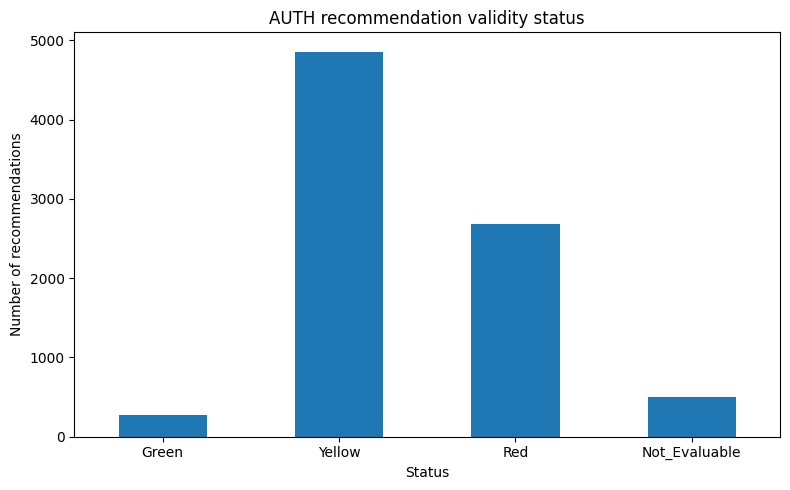

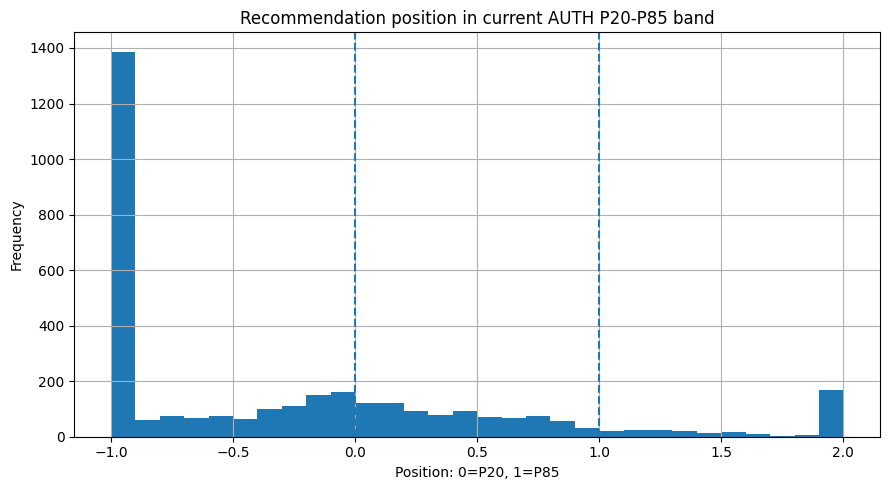

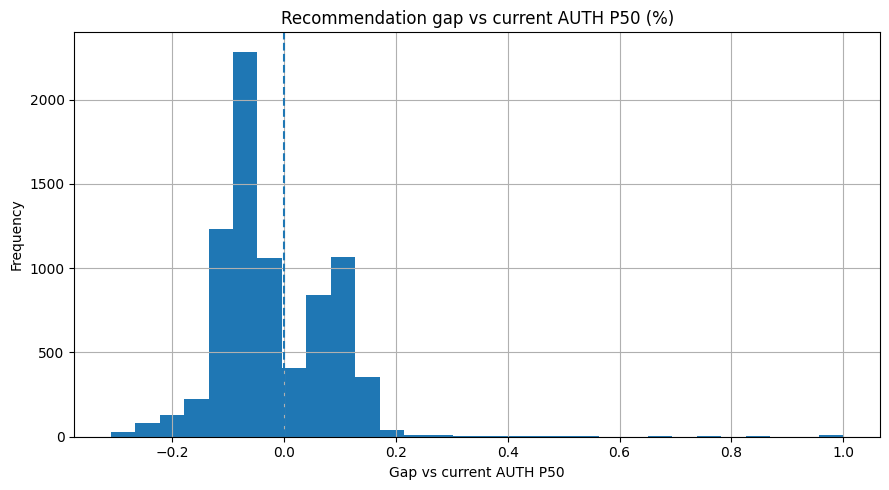

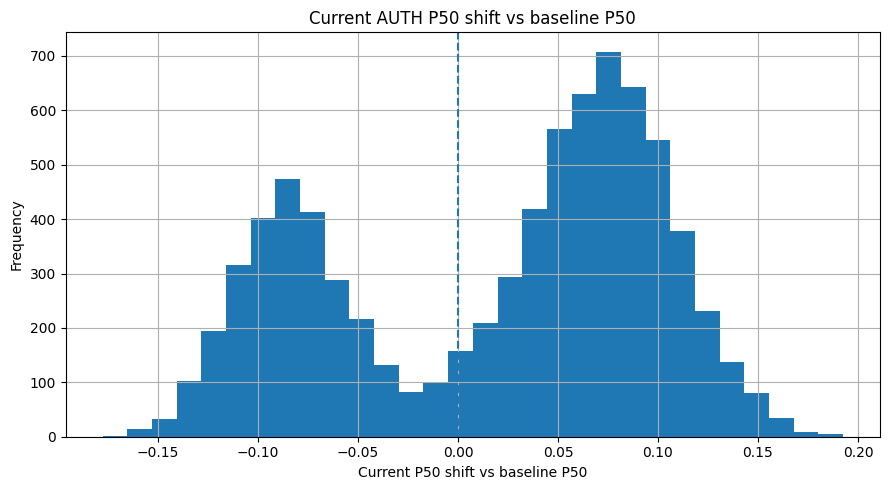

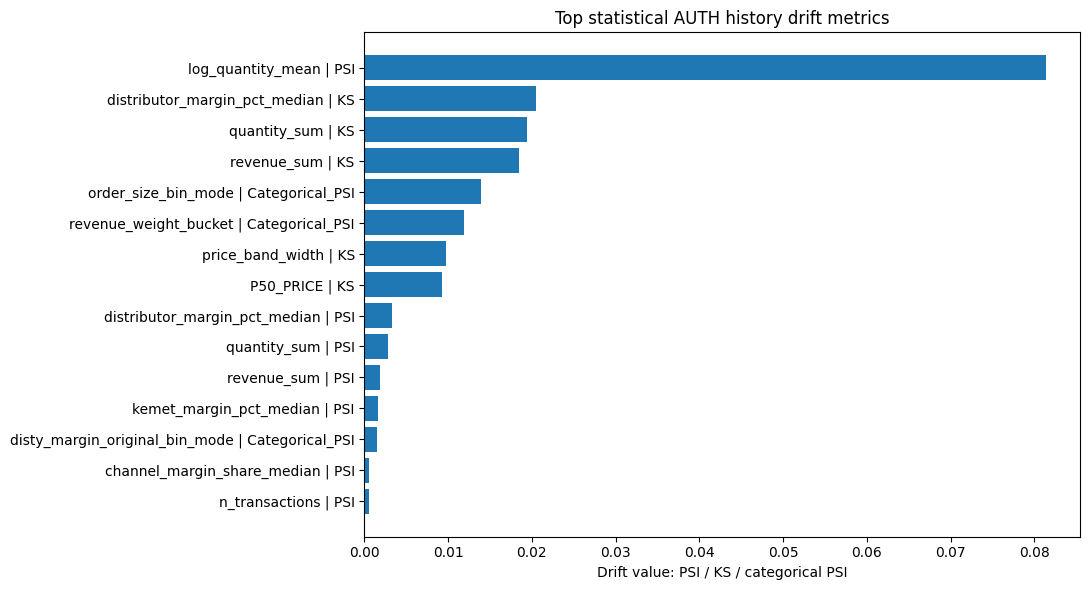

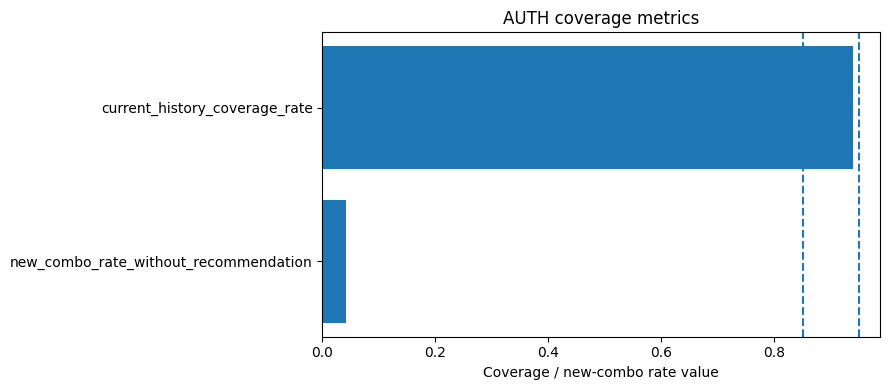

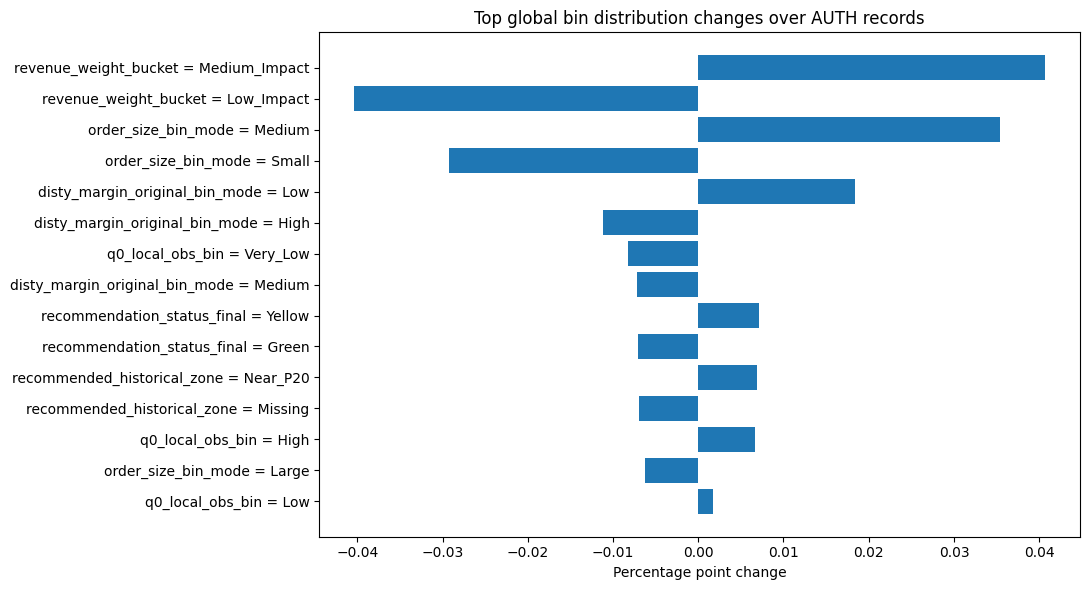

,figure_name,figure_title,figure_path,drift_run_id
0,auth_recommendation_validity_status.png,AUTH recommendation validity status,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\auth_recommendation_validity_status.png,20260601T042547Z_auth_recommendation_validity_v1
1,recommendation_position_current_auth_band.png,Recommendation position in current AUTH band,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\recommendation_position_current_auth_band.png,20260601T042547Z_auth_recommendation_validity_v1
2,recommendation_gap_vs_current_auth_p50_pct.png,Recommendation gap vs current AUTH P50,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\recommendation_gap_vs_current_auth_p50_pct.png,20260601T042547Z_auth_recommendation_validity_v1
3,current_auth_p50_shift_vs_baseline_pct.png,Current AUTH P50 shift vs baseline P50,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\current_auth_p50_shift_vs_baseline_pct.png,20260601T042547Z_auth_recommendation_validity_v1
4,top_statistical_auth_history_drift_metrics.png,Top statistical AUTH history drift metrics,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\top_statistical_auth_history_drift_metrics.png,20260601T042547Z_auth_recommendation_validity_v1
5,auth_coverage_metrics.png,AUTH coverage metrics,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\auth_coverage_metrics.png,20260601T042547Z_auth_recommendation_validity_v1
6,top_global_bin_changes_auth_scope.png,Top global bin changes over AUTH records,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\top_global_bin_changes_auth_scope.png,20260601T042547Z_auth_recommendation_validity_v1


In [14]:
# =========================================================
# 11. Visualizations
# =========================================================

figures_manifest = []

def save_current_figure(filename, title):
    path = OUTPUT_DIRS["figures"] / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    figures_manifest.append({
        "figure_name": filename,
        "figure_title": title,
        "figure_path": str(path),
        "drift_run_id": DRIFT_RUN_ID,
    })
    plt.show()

# Status counts.
status_counts = validity_df["auth_recommendation_validity_status"].value_counts().reindex(["Green", "Yellow", "Red", "Not_Evaluable"], fill_value=0)
plt.figure(figsize=(8, 5))
status_counts.plot(kind="bar")
plt.title("AUTH recommendation validity status")
plt.xlabel("Status")
plt.ylabel("Number of recommendations")
plt.xticks(rotation=0)
save_current_figure("auth_recommendation_validity_status.png", "AUTH recommendation validity status")

# Recommendation position distribution.
if "recommendation_position_current_auth_band" in validity_df.columns:
    plt.figure(figsize=(9, 5))
    validity_df["recommendation_position_current_auth_band"].replace([np.inf, -np.inf], np.nan).dropna().clip(-1, 2).hist(bins=30)
    plt.axvline(0, linestyle="--")
    plt.axvline(1, linestyle="--")
    plt.title("Recommendation position in current AUTH P20-P85 band")
    plt.xlabel("Position: 0=P20, 1=P85")
    plt.ylabel("Frequency")
    save_current_figure("recommendation_position_current_auth_band.png", "Recommendation position in current AUTH band")

# Gap vs current P50.
if "recommendation_gap_vs_current_auth_p50_pct" in validity_df.columns:
    plt.figure(figsize=(9, 5))
    validity_df["recommendation_gap_vs_current_auth_p50_pct"].replace([np.inf, -np.inf], np.nan).dropna().clip(-1, 1).hist(bins=30)
    plt.axvline(0, linestyle="--")
    plt.title("Recommendation gap vs current AUTH P50 (%)")
    plt.xlabel("Gap vs current AUTH P50")
    plt.ylabel("Frequency")
    save_current_figure("recommendation_gap_vs_current_auth_p50_pct.png", "Recommendation gap vs current AUTH P50")

# Current P50 shift vs baseline P50.
if "current_auth_p50_shift_vs_baseline_pct" in validity_df.columns:
    plt.figure(figsize=(9, 5))
    validity_df["current_auth_p50_shift_vs_baseline_pct"].replace([np.inf, -np.inf], np.nan).dropna().clip(-1, 1).hist(bins=30)
    plt.axvline(0, linestyle="--")
    plt.title("Current AUTH P50 shift vs baseline P50")
    plt.xlabel("Current P50 shift vs baseline P50")
    plt.ylabel("Frequency")
    save_current_figure("current_auth_p50_shift_vs_baseline_pct.png", "Current AUTH P50 shift vs baseline P50")

# History drift top metrics.
# Coverage rates are not directly comparable with PSI/KS values.
# Therefore, statistical drift metrics and coverage metrics are visualized separately.
statistical_history_drift = input_history_drift_log[
    input_history_drift_log["drift_metric"].isin(["PSI", "KS", "Categorical_PSI"])
].dropna(subset=["drift_value"]).sort_values("drift_value", ascending=False).head(15)

if not statistical_history_drift.empty:
    plt.figure(figsize=(11, 6))
    labels = statistical_history_drift["variable_name"] + " | " + statistical_history_drift["drift_metric"]
    plt.barh(labels, statistical_history_drift["drift_value"])
    plt.title("Top statistical AUTH history drift metrics")
    plt.xlabel("Drift value: PSI / KS / categorical PSI")
    plt.gca().invert_yaxis()
    save_current_figure("top_statistical_auth_history_drift_metrics.png", "Top statistical AUTH history drift metrics")

coverage_history_metrics = input_history_drift_log[
    input_history_drift_log["drift_metric"] == "Coverage_Rate"
].copy()

if not coverage_history_metrics.empty:
    plt.figure(figsize=(9, 4))
    labels = coverage_history_metrics["variable_name"]
    plt.barh(labels, coverage_history_metrics["drift_value"])
    plt.axvline(CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD, linestyle="--")
    plt.axvline(CURRENT_HISTORY_COVERAGE_RED_THRESHOLD, linestyle="--")
    plt.title("AUTH coverage metrics")
    plt.xlabel("Coverage / new-combo rate value")
    plt.gca().invert_yaxis()
    save_current_figure("auth_coverage_metrics.png", "AUTH coverage metrics")

# Bin drift top changes.
if not bin_drift_summary.empty:
    top_bins = bin_drift_summary.head(15).copy()
    plt.figure(figsize=(11, 6))
    labels = top_bins["column_name"] + " = " + top_bins["bin_value"]
    plt.barh(labels, top_bins["pct_point_change"])
    plt.title("Top global bin distribution changes over AUTH records")
    plt.xlabel("Percentage point change")
    plt.gca().invert_yaxis()
    save_current_figure("top_global_bin_changes_auth_scope.png", "Top global bin changes over AUTH records")

figures_manifest_df = pd.DataFrame(figures_manifest)
display(figures_manifest_df)

## 12. Exportación de artefactos MLOps

Esta sección exporta artefactos para trazabilidad, monitoreo y futura conexión con Azure/SQL/Storage.

In [15]:
# =========================================================
# 12. Export artifacts
# =========================================================

# Snapshot-like outputs.
baseline_recommendation_snapshot.to_csv(OUTPUT_DIRS["snapshots"] / "baseline_recommendation_snapshot.csv", index=False)
baseline_auth_history_profile.to_csv(OUTPUT_DIRS["snapshots"] / "baseline_auth_history_profile.csv", index=False)
current_auth_history.to_csv(OUTPUT_DIRS["snapshots"] / "current_auth_history_snapshot_simulated.csv", index=False)
validity_df.to_csv(OUTPUT_DIRS["logs"] / "auth_recommendation_validity_log.csv", index=False)
new_combo_log.to_csv(OUTPUT_DIRS["logs"] / "new_combo_without_baseline_recommendation_log.csv", index=False)

# Logs and summaries.
data_quality_log.to_csv(OUTPUT_DIRS["logs"] / "data_quality_log.csv", index=False)
quality_status_summary.to_csv(OUTPUT_DIRS["summaries"] / "quality_status_summary.csv", index=False)
input_history_drift_log.to_csv(OUTPUT_DIRS["logs"] / "auth_history_drift_log.csv", index=False)
validity_summary.to_csv(OUTPUT_DIRS["summaries"] / "auth_recommendation_validity_summary.csv", index=False)
validity_revenue_summary.to_csv(OUTPUT_DIRS["summaries"] / "auth_recommendation_validity_revenue_summary.csv", index=False)
segment_validity_summary.to_csv(OUTPUT_DIRS["summaries"] / "segment_validity_summary.csv", index=False)
top_recommendation_review_cases.to_csv(OUTPUT_DIRS["summaries"] / "top_recommendation_review_cases.csv", index=False)
bin_drift_summary.to_csv(OUTPUT_DIRS["summaries"] / "global_bin_drift_auth_scope_summary.csv", index=False)
run_readiness_summary_df.to_csv(OUTPUT_DIRS["summaries"] / "run_readiness_summary.csv", index=False)
recommendation_source_metadata_df.to_csv(OUTPUT_DIRS["summaries"] / "recommendation_source_metadata.csv", index=False)
if "segment_dashboard_summary" in globals():
    segment_dashboard_summary.to_csv(OUTPUT_DIRS["summaries"] / "segment_dashboard_summary.csv", index=False)
figures_manifest_df.to_csv(OUTPUT_DIRS["manifest"] / "figures_manifest.csv", index=False)

# JSON summary for SQL/API-style consumption.
with open(OUTPUT_DIRS["summaries"] / "run_readiness_summary.json", "w", encoding="utf-8") as f:
    json.dump(run_readiness_summary, f, indent=2, ensure_ascii=False)

with open(OUTPUT_DIRS["summaries"] / "simulation_summary.json", "w", encoding="utf-8") as f:
    json.dump(simulation_summary, f, indent=2, ensure_ascii=False)

# Optional parquet outputs.
parquet_candidates = {
    "current_auth_history_snapshot_simulated.parquet": current_auth_history,
    "auth_recommendation_validity_log.parquet": validity_df,
    "auth_history_drift_log.parquet": input_history_drift_log,
    "data_quality_log.parquet": data_quality_log,
    "segment_validity_summary.parquet": segment_validity_summary,
    "global_bin_drift_auth_scope_summary.parquet": bin_drift_summary,
    "segment_dashboard_summary.parquet": segment_dashboard_summary if "segment_dashboard_summary" in globals() else pd.DataFrame(),
}

for filename, df in parquet_candidates.items():
    try:
        if filename.endswith("summary.parquet") or "summary" in filename:
            df.to_parquet(OUTPUT_DIRS["summaries"] / filename, index=False)
        else:
            df.to_parquet(OUTPUT_DIRS["logs"] / filename, index=False)
    except Exception as e:
        print(f"Parquet export skipped for {filename}: {e}")

print("Artifacts exported to:", OUTPUT_ROOT)

Parquet export skipped for data_quality_log.parquet: ("Could not convert 'AUTH_AND_NON_AUTH_GLOBAL' with type str: tried to convert to double", 'Conversion failed for column observed_value with type object')
Artifacts exported to: avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1


## 13. Reporte narrativo automático

Este reporte no calcula métricas nuevas. Consolida los resultados para revisión humana y para evidencia académica.

In [16]:
# =========================================================
# 13. Narrative monitoring report
# =========================================================

top_alerts = (
    validity_df[validity_df["auth_recommendation_validity_status"].isin(["Red", "Yellow", "Not_Evaluable"])]
    .sort_values(["auth_recommendation_validity_status", "baseline_revenue_sum_numeric"], ascending=[False, False])
    .head(20)
)

top_history_alerts = (
    input_history_drift_log[input_history_drift_log["drift_status"].isin(["Red", "Yellow"])]
    .sort_values(["drift_status", "drift_value"], ascending=[False, False])
    .head(15)
)

report_lines = []
report_lines.append("# Avance 4 - AUTH Recommendation Validity vs Current AUTH History")
report_lines.append("")
report_lines.append(f"**Drift run ID:** {DRIFT_RUN_ID}")
report_lines.append(f"**Timestamp UTC:** {RUN_TIMESTAMP_UTC.isoformat()}")
report_lines.append(f"**Monitoring scope:** {MONITORING_SCOPE}")
report_lines.append(f"**Runs model:** {RUNS_MODEL}")
report_lines.append(f"**Baseline snapshot:** `{BASELINE_SNAPSHOT_PATH}`")
report_lines.append(f"**Recommendation source column:** `{RECOMMENDATION_PRICE_COLUMN}`")
report_lines.append(f"**Bin catalog scope:** `{BIN_CATALOG_SCOPE}`")
report_lines.append(f"**Bin catalog version:** `{BIN_CATALOG_VERSION}`")
report_lines.append("")

report_lines.append("## Interpretación del alcance")
report_lines.append("")
report_lines.append("Esta etapa utiliza únicamente datos AUTH. Por lo tanto, los percentiles P20, P50 y P85 representan historia de precios autorizados, no mercado completo. El objetivo es validar si la recomendación vigente sigue siendo coherente con la historia AUTH actual observada o simulada.")
report_lines.append("")
report_lines.append("Los catálogos de bins fueron creados con todos los datos disponibles (AUTH + no AUTH). En este notebook no se recalculan esos catálogos; se monitorea la distribución de registros AUTH dentro de los bins ya definidos/versionados.")
report_lines.append("")
report_lines.append("La corrida current es simulada debido a que los datos reales posteriores al baseline aún están pendientes de entrega. Esta simulación valida el contrato operativo del monitoreo; no se interpreta como drift real observado de negocio.")
report_lines.append("")

report_lines.append("## Resumen global")
report_lines.append("")
for key in [
    "baseline_recommendation_rows", "current_auth_history_rows", "new_combo_count", "new_combo_rate",
    "current_history_coverage_rate", "data_quality_status", "auth_history_drift_status",
    "recommendation_validity_global_status", "run_readiness_status", "run_readiness_decision",
    "green_recommendation_rate", "yellow_recommendation_rate", "red_recommendation_rate", "not_evaluable_recommendation_rate",
    "red_revenue_share", "yellow_revenue_share",
]:
    report_lines.append(f"- **{key}:** {run_readiness_summary.get(key)}")
report_lines.append("")

report_lines.append("## Principales alertas de vigencia de recomendación")
report_lines.append("")
if top_alerts.empty:
    report_lines.append("No se detectaron recomendaciones en estado Yellow, Red o Not_Evaluable.")
else:
    cols = KEY_COLUMNS + ["baseline_recommended_price", "current_P20_PRICE", "current_P50_PRICE", "current_P85_PRICE", "auth_recommendation_validity_status", "auth_recommendation_validity_reason", "recommended_action", "baseline_revenue_sum_numeric"]
    cols = [c for c in cols if c in top_alerts.columns]
    report_lines.append(top_alerts[cols].to_markdown(index=False))
report_lines.append("")

report_lines.append("## Principales alertas de historia AUTH")
report_lines.append("")
if top_history_alerts.empty:
    report_lines.append("No se detectaron métricas de historia AUTH en estado Yellow o Red.")
else:
    cols = ["monitoring_stage", "variable_name", "drift_metric", "drift_value", "drift_status", "recommended_action"]
    report_lines.append(top_history_alerts[cols].to_markdown(index=False))
report_lines.append("")

report_lines.append("## Principales cambios en bins globales sobre AUTH")
report_lines.append("")
if bin_drift_summary.empty:
    report_lines.append("No se encontraron columnas de bins disponibles.")
else:
    report_lines.append(bin_drift_summary.head(15).to_markdown(index=False))
report_lines.append("")

report_lines.append("## Evidencia visual")
report_lines.append("")
report_lines.append(f"Las figuras se guardaron en: `{OUTPUT_DIRS['figures']}`")
report_lines.append("")

report_lines.append("## Siguiente paso con datos reales")
report_lines.append("")
report_lines.append("Cuando se reciban los datos reales posteriores, se deberá generar un `current_auth_history_snapshot` real usando la misma llave `kpn + vpareadescription + distysegment`, aplicar el mismo catálogo de bins versionado y reemplazar el snapshot simulado. La lógica de data quality, drift de historia AUTH y vigencia de recomendación puede ejecutarse sin correr el modelo de recomendación.")

report_path = OUTPUT_DIRS["reports"] / "auth_recommendation_validity_monitoring_report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Report exported:", report_path)

Report exported: avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\reports\auth_recommendation_validity_monitoring_report.md


## 14. Artifact manifest

El manifest funciona como índice auditable de los archivos generados por la corrida.

In [17]:
# =========================================================
# 14. Artifact manifest
# =========================================================

def file_sha256(path):
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

artifact_records = []
for file_path in OUTPUT_ROOT.rglob("*"):
    if file_path.is_file():
        artifact_records.append({
            "drift_run_id": DRIFT_RUN_ID,
            "artifact_name": file_path.name,
            "artifact_path": str(file_path),
            "artifact_group": file_path.parent.name,
            "file_size_bytes": file_path.stat().st_size,
            "sha256": file_sha256(file_path),
            "created_at_utc": RUN_TIMESTAMP_UTC.isoformat(),
        })

artifact_manifest = pd.DataFrame(artifact_records).sort_values(["artifact_group", "artifact_name"])
artifact_manifest_path = OUTPUT_DIRS["manifest"] / "artifact_manifest.csv"
artifact_manifest.to_csv(artifact_manifest_path, index=False)

with open(OUTPUT_DIRS["manifest"] / "artifact_manifest.json", "w", encoding="utf-8") as f:
    json.dump(artifact_manifest.to_dict(orient="records"), f, indent=2, ensure_ascii=False)

display(artifact_manifest)
print("Artifact manifest exported:", artifact_manifest_path)

,drift_run_id,artifact_name,artifact_path,artifact_group,file_size_bytes,sha256,created_at_utc
0,20260601T042547Z_auth_recommendation_validity_v1,auth_coverage_metrics.png,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\auth_coverage_metrics.png,figures,31172,aa8f312d65cf3208b3342d7712897a0033bf2012d3c41cf5e779ec14fc2d9a5a,2026-06-01T04:25:47.338517+00:00
1,20260601T042547Z_auth_recommendation_validity_v1,auth_recommendation_validity_status.png,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\auth_recommendation_validity_status.png,figures,35012,ceea3a1497b2996813423000792836dca8aa64905a5322dd82ba30388d2e43c3,2026-06-01T04:25:47.338517+00:00
2,20260601T042547Z_auth_recommendation_validity_v1,current_auth_p50_shift_vs_baseline_pct.png,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\current_auth_p50_shift_vs_baseline_pct.png,figures,38153,6bdc78e988377e28592cd376fbef5f533073fcd93a15bbc1e002674fd3fa0faf,2026-06-01T04:25:47.338517+00:00
3,20260601T042547Z_auth_recommendation_validity_v1,recommendation_gap_vs_current_auth_p50_pct.png,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\recommendation_gap_vs_current_auth_p50_pct.png,figures,35192,23dd730283ebfad5dfe10ca219b7b1a0445e7d5a6486331cb07cbf1e5ae3958b,2026-06-01T04:25:47.338517+00:00
4,20260601T042547Z_auth_recommendation_validity_v1,recommendation_position_current_auth_band.png,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\recommendation_position_current_auth_band.png,figures,39143,3aac15c5722d32999c7dee8a734500f63f24eb21efc3d37baa46243517d0b844,2026-06-01T04:25:47.338517+00:00
5,20260601T042547Z_auth_recommendation_validity_v1,top_global_bin_changes_auth_scope.png,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\top_global_bin_changes_auth_scope.png,figures,96113,007340e5d532a4ae264bd949bc3c0b0935be283091f5f3b2a7beabb1c7357960,2026-06-01T04:25:47.338517+00:00
6,20260601T042547Z_auth_recommendation_validity_v1,top_statistical_auth_history_drift_metrics.png,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\figures\top_statistical_auth_history_drift_metrics.png,figures,88816,3166e43aae61de9317e7779cfb03c1f798392dc87b5fee531208ada9ce6b7084,2026-06-01T04:25:47.338517+00:00
7,20260601T042547Z_auth_recommendation_validity_v1,auth_history_drift_log.csv,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\logs\auth_history_drift_log.csv,logs,7301,95ea319586f4be4e792ffed0a7795e559d71336704d8724890b8bdea51d26504,2026-06-01T04:25:47.338517+00:00
8,20260601T042547Z_auth_recommendation_validity_v1,auth_history_drift_log.parquet,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\logs\auth_history_drift_log.parquet,logs,9187,15010678e75f06f395e0a487dbbaffca280cdefbd427e75abae0610392b5f184,2026-06-01T04:25:47.338517+00:00
9,20260601T042547Z_auth_recommendation_validity_v1,auth_recommendation_validity_log.csv,avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\logs\auth_recommendation_validity_log.csv,logs,16329265,bfbe12b9435f8ac0e3d8a093301f5ffae3aa29f6e2a73b419a639e641c3caa51,2026-06-01T04:25:47.338517+00:00


Artifact manifest exported: avance4_outputs\20260601T042547Z_auth_recommendation_validity_v1\manifest\artifact_manifest.csv


## 15. Cierre del Avance 4

Este notebook deja implementada la compuerta principal de monitoreo pre-model para el alcance AUTH:

1. Valida calidad de datos.
2. Evalúa drift de historia AUTH.
3. Evalúa si la recomendación vigente sigue alineada con la historia AUTH actual.
4. Identifica casos y segmentos que requieren revisión.
5. Exporta artefactos listos para almacenamiento en Azure Storage/ADLS y registro resumido en Azure SQL.

La lógica no reemplaza al modelo de recomendación. Su función es decidir si la recomendación vigente puede mantenerse, si requiere revisión o si se justifica una nueva corrida/recalibración.

## Lectura final recomendada

La etapa queda cerrada como una compuerta AUTH-only pre-model. El resultado Red/Yellow/Green no debe entenderse como un juicio absoluto del modelo, sino como una señal de operación:

- **Green:** la recomendación vigente puede mantenerse con monitoreo normal.
- **Yellow:** la recomendación sigue siendo defendible, pero requiere revisión por cambio moderado en historia AUTH o cercanía a extremos.
- **Red:** la recomendación vigente requiere revisión antes de confiar en ella; puede justificar una nueva corrida, recalibración o revisión con PM/Pricing.

El siguiente trabajo ya no es seguir modificando la lógica del notebook, sino conectarla a la arquitectura MLOps: Storage/ADLS para evidencia completa, Azure SQL para metadatos y resúmenes, y dashboard para monitoreo operativo.
